# Advanced Models — Transformer / SINDy / Mamba (Colab + GPU)

**Purpose.** Train and evaluate three forecasting model families
(**Transformer**, **POD-SINDy**, **Mamba**) on the OpenMRG dataset
(Gothenburg, Summer 2015), in both *single-step* (one model per horizon)
and *multi-step* (one model for all horizons) modes, and benchmark them
against **naive persistence** baselines and the project's
**CML estimation model**.

This notebook is **self-contained**: a new user with a fresh Drive can
run it top-to-bottom without any other notebook from the project. Every
download, extraction, sweep and training step is wrapped in an existence
check so reruns just load cached outputs from Drive.

## What gets built (and saved to Drive)

| Stage | Output (under `data/processed/`) |
|-------|----------------------------------|
| Estimation NN (CML→rain at t)        | `estimation_cml.npy` *(T, H, W)*           |
| Naive radar persistence              | `naive_radar_{15,30,45,60}min.npy`         |
| Naive gauge persistence (IDW)        | `naive_gauge_{15,30,45,60}min.npy`         |
| Transformer single-step              | `forecast_transformer_h{1..4}.npy`         |
| Transformer multi-step               | `forecast_transformer_multi.npy`           |
| SINDy single-step                    | `forecast_sindy_h{1..4}.npy`               |
| SINDy multi-step                     | `forecast_sindy_multi.npy`                 |
| Mamba single-step                    | `forecast_mamba_h{1..4}.npy`               |
| Mamba multi-step                     | `forecast_mamba_multi.npy`                 |

Trained checkpoints land in `models/`.


## Terminology glossary

Read this once — every later cell uses these names.

| Name | What it is | Output shape | Notes |
|------|------------|--------------|-------|
| **`model_cml`** | Closed-form physical CML estimator (`pynncml.one_step_dynamic_baseline`) IDW'd to the radar grid. | `(T, H, W)` | Estimation at time `t`. No NN. |
| **`estimation_cml`** | Two-step GRU NN trained on `(rain_rate[t])` → estimates rain at the same time `t`. IDW'd to the radar grid. | `(T, H, W)` | The map sequence used as **input** to the spatial forecasters below. |
| **`naive_h_radar`** | Persistence on the radar field: `pred[t] = radar[t-h]`. | `(T, H, W)` per `h` | Strongest naive baseline. |
| **`naive_h_gauge`** | IDW of rain gauges + persistence: `pred[t] = gauge_idw[t-h]`. | `(T, H, W)` per `h` | Sparse-source baseline. |
| **`forecast_transformer_h{h}`** | Transformer encoder trained on a *lookback* of `estimation_cml` maps to predict the map `h` steps ahead. **One model per horizon** (single-step). | `(T', H, W)` | `T' = T - lookback - h + 1`. |
| **`forecast_transformer_multi`** | Same architecture but **one model that emits all horizons at once** (multi-step decoder). | `(H_out, T', H, W)` | Stack of all horizons. |
| **`forecast_sindy_h{h}`** | POD reduction of `estimation_cml` (TruncatedSVD), then symbolic dynamics learned by `pysindy.STLSQ`, integrated `h` steps forward. **One model per horizon**. | `(T', H, W)` | The SINDy *equations* are the same per horizon; only the integration time differs. |
| **`forecast_sindy_multi`** | SINDy run **once** and integrated `h` steps for `h=1..4` using the same fitted equations. | `(H_out, T', H, W)` | |
| **`forecast_mamba_h{h}`** | GRU-based simple Mamba surrogate (state-space), one per horizon. | `(T', H, W)` | |
| **`forecast_mamba_multi`** | Same SSM architecture with multi-horizon head. | `(H_out, T', H, W)` | |

**Lookback** = `8` frames = `2 hours`.
**Horizons** = `[1, 2, 3, 4]` 15-min steps = `[15, 30, 45, 60]` minutes.

### Single-step vs multi-step

* **Single-step**: train a separate model for each horizon `h`. Pros — each
  model is specialized; no error compounding. Cons — `H` checkpoints, `H×`
  training cost, no shared structure across horizons.
* **Multi-step**: one model emits all `H` horizons in one forward pass
  (a wider prediction head). Pros — single checkpoint, learns shared
  features. Cons — early horizons compete with late ones in the loss.

Both are reported side-by-side so you can see the trade-off.


## Cell 3 — GPU & Drive

Mount Drive once, define `BASE_DIR` and the file paths every later cell
uses, detect the GPU, and bail out (with a warning) if running on CPU.


In [1]:
import os, sys, warnings, time
import torch

# --- Drive ---------------------------------------------------------------
from google.colab import drive
if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

BASE_DIR        = "/content/drive/MyDrive/FieldSense_Project"
DATA_DIR        = os.path.join(BASE_DIR, "data")
PROCESSED_DIR   = os.path.join(DATA_DIR, "processed")
MODELS_DIR      = os.path.join(BASE_DIR, "models")
RAW_DIR         = os.path.join(DATA_DIR, "raw")
RADAR_NPY       = os.path.join(PROCESSED_DIR, "radar_maps_15min.npy")
RADAR_TIMES_NPY = os.path.join(PROCESSED_DIR, "radar_maps_15min_times.npy")
RADAR_NC        = os.path.join(DATA_DIR, "radar", "radar.nc")
for d in (PROCESSED_DIR, MODELS_DIR, RAW_DIR, os.path.dirname(RADAR_NC)):
    os.makedirs(d, exist_ok=True)

# --- GPU -----------------------------------------------------------------
if torch.cuda.is_available():
    device   = torch.device("cuda:0")
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU available     : {gpu_name}   ({gpu_mem:.1f} GB)")
else:
    device   = torch.device("cpu")
    warnings.warn(
        "!!! NO GPU detected — switch the Colab runtime to GPU "
        "(Runtime → Change runtime type → T4 GPU). The Transformer / "
        "Mamba sweeps will be very slow on CPU."
    )
    print("GPU available     : NO  (running on CPU)")

print(f"torch version     : {torch.__version__}")
print(f"device            : {device}\n")
print(f"BASE_DIR          : {BASE_DIR}")
print(f"PROCESSED_DIR     : {PROCESSED_DIR}")
print(f"MODELS_DIR        : {MODELS_DIR}")

# ---------------------------------------------------------------
# RESET flag — when True, the next cell wipes every advanced-model
# artefact (Transformer / SINDy / Mamba checkpoints + sweep configs +
# forecast .npy outputs) so the rest of the notebook re-trains from
# scratch. When False, cached files are reused and training is skipped.
# Estimation NN, naive baselines, IDW weights and pynncml caches are
# NEVER touched by RESET (re-running them is too expensive).
# ---------------------------------------------------------------
RESET = False
print(f"RESET = {RESET}  (set True to force a full retrain of TF/SINDy/Mamba)")

Mounted at /content/drive
GPU available     : NVIDIA L4   (22.0 GB)
torch version     : 2.10.0+cu128
device            : cuda:0

BASE_DIR          : /content/drive/MyDrive/FieldSense_Project
PROCESSED_DIR     : /content/drive/MyDrive/FieldSense_Project/data/processed
MODELS_DIR        : /content/drive/MyDrive/FieldSense_Project/models
RESET = False  (set True to force a full retrain of TF/SINDy/Mamba)


## Cell 3b — RESET cleanup (only runs when RESET=True)

When `RESET = True` (set in the previous cell), wipe every cached
artefact for the **advanced models** (Transformer / SINDy / Mamba) so
the notebook will retrain them from scratch.

What gets wiped (in `MODELS_DIR/` and `PROCESSED_DIR/`):

| Pattern | What |
|---------|------|
| `transformer_*.pth`, `transformer_sweep_best.json` | TF checkpoints + sweep hp |
| `mamba_*.pth`,       `mamba_sweep_best.json`       | Mamba checkpoints + sweep hp |
| `sindy_*.pkl`                                       | SINDy fitted SVD + equations |
| `forecast_transformer_*.npy`, `forecast_sindy_*.npy`, `forecast_mamba_*.npy` | All advanced-model predictions |

What stays untouched:

| Kept | Why |
|------|-----|
| `radar_maps_15min.npy`, gauges, IDW weights | Deterministic raw / pre-processed data |
| `naive_radar_*.npy`, `naive_gauge_*.npy`     | Trivial baselines, instant |
| `model_cml*.npy`, `estimation_cml.npy`, `best_estimation_model.pt` | Estimation pipeline — slow to rebuild, not affected by NaN bug |
| `openmrg_*.pkl`                                | pynncml dataset cache |


In [2]:
import glob

if not RESET:
    print("RESET = False — skipping cleanup. Cached files will be reused.")
else:
    print("RESET = True — wiping advanced-model artefacts ...")
    patterns = []
    # Models
    for p in ("transformer_*.pth", "transformer_sweep_best.json",
              "mamba_*.pth",       "mamba_sweep_best.json",
              "sindy_*.pkl"):
        patterns.append(os.path.join(MODELS_DIR, p))
    # Processed predictions
    for p in ("forecast_transformer_*.npy",
              "forecast_sindy_*.npy",
              "forecast_mamba_*.npy",
              "gauge_field_full.npy"):
        patterns.append(os.path.join(PROCESSED_DIR, p))

    deleted = []
    for pat in patterns:
        for f in glob.glob(pat):
            try:
                os.remove(f); deleted.append(f)
            except OSError as e:
                print(f"  ! failed to delete {f}: {e}")
    print(f"Deleted {len(deleted)} files:")
    for f in deleted:
        print(f"  rm {f}")

RESET = False — skipping cleanup. Cached files will be reused.


## Cell 4 — Imports + pip installs

Install missing wheels (no-op if already present), then bring every
module the rest of the notebook needs into scope.


In [3]:
import importlib, subprocess

PKGS = ["pynncml", "wandb", "netCDF4", "h5netcdf", "xarray", "tqdm",
        "pysindy", "scikit-learn", "scipy", "matplotlib"]
for pkg in PKGS:
    try:
        importlib.import_module(pkg.replace("-", "_"))
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import math, pickle, hashlib, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from tqdm import tqdm
import scipy.stats
from scipy.spatial import cKDTree
from scipy.interpolate import RegularGridInterpolator
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import f1_score, confusion_matrix

import torch.nn as nn
import torch.nn.functional as F

import pynncml as pnc
import wandb
import pysindy as ps

# Patch xarray to default to netcdf4 engine (workaround on some Colab images).
# IDEMPOTENT: stash the truly-original on the module so re-running this cell
# doesn't wrap the wrapper (which causes RecursionError on the next open).
if not getattr(xr, "_fs_patched", False):
    xr._fs_orig_open = xr.open_dataset
    def _fs_open(*a, **kw):
        kw.setdefault("engine", "netcdf4")
        return xr._fs_orig_open(*a, **kw)
    xr.open_dataset = _fs_open
    xr._fs_patched = True

print("All imports OK.")
print(f"  pynncml : {getattr(pnc, '__version__', 'unknown')}")
print(f"  pysindy : {getattr(ps, '__version__', 'unknown')}")
print(f"  wandb   : {getattr(wandb, '__version__', 'unknown')}")

Installing pynncml ...
Installing pysindy ...
Installing scikit-learn ...
All imports OK.
  pynncml : 0.3.7
  pysindy : 2.1.0
  wandb   : 0.26.1


## Cell 5 — Train / Validation / Test splits

Identical to every other notebook in the project.


In [4]:
splits_cfg = {
    "Train": slice("2015-06-01", "2015-07-20"),
    "Val":   slice("2015-07-21", "2015-08-05"),
    "Test":  slice("2015-08-06", "2015-08-31"),
}
FULL_SLICE = slice("2015-06-01", "2015-08-31")

print("Chronological splits:")
for name, sl in splits_cfg.items():
    n_15 = ((pd.Timestamp(sl.stop) + pd.Timedelta(days=1) -
             pd.Timestamp(sl.start)).total_seconds()) / (15 * 60)
    print(f"  {name:<5s}: {sl.start}  →  {sl.stop}   ({int(n_15):,} 15-min slots)")
print(f"  Full : {FULL_SLICE.start}  →  {FULL_SLICE.stop}")

# Forecasting hyper-parameters used across all model families
LOOKBACK_WINDOW = 8                         # 8 * 15 min = 2 h of history
HORIZONS_STEPS  = [1, 2, 3, 4]              # 15-min steps
HORIZONS_MIN    = [h * 15 for h in HORIZONS_STEPS]
print(f"\nLookback window : {LOOKBACK_WINDOW} frames ({LOOKBACK_WINDOW*15} min)")
print(f"Horizons        : {HORIZONS_STEPS} steps  → {HORIZONS_MIN} min")

Chronological splits:
  Train: 2015-06-01  →  2015-07-20   (4,800 15-min slots)
  Val  : 2015-07-21  →  2015-08-05   (1,536 15-min slots)
  Test : 2015-08-06  →  2015-08-31   (2,496 15-min slots)
  Full : 2015-06-01  →  2015-08-31

Lookback window : 8 frames (120 min)
Horizons        : [1, 2, 3, 4] steps  → [15, 30, 45, 60] min


## Cell 6 — OpenMRG data check (pynncml auto-downloads if missing)

Just inventories the existing data on Drive. We do **not** manually
download anything: `pynncml.datasets.loader_open_mrg_dataset` (Cell 7)
auto-downloads the OpenMRG bundle on first call and extracts it under
`data_path`. If you've already run `radar_gauge_analysis_colab.ipynb`
or `models_naive_estimation_colab.ipynb`, the data is already there.

If you ever need to download manually (e.g. a clean Drive), the
canonical Zenodo record is:
**https://zenodo.org/record/7674581** (OpenMRG, Andersson et al., 2023).


In [5]:
# Inventory what's on Drive — pynncml will fetch missing pieces in Cell 7.
print("DATA_DIR contents:")
if os.path.exists(DATA_DIR):
    for f in sorted(os.listdir(DATA_DIR)):
        full = os.path.join(DATA_DIR, f)
        if os.path.isdir(full):
            n = len(os.listdir(full))
            print(f"  {f}/   ({n} entries)")
        else:
            sz = os.path.getsize(full) / 1024**2
            print(f"  {f}   ({sz:.1f} MB)")
else:
    print(f"  (DATA_DIR {DATA_DIR} is empty — pynncml will populate it on first call)")

# Sanity-check the canonical sub-paths the rest of the notebook expects.
expected = {
    "CML zip"     : os.path.join(DATA_DIR, "cml", "cml.zip"),
    "gauge dir"   : os.path.join(DATA_DIR, "gauge"),
    "radar netcdf": RADAR_NC,
}
print("\nKey paths:")
for label, p in expected.items():
    print(f"  {label:<14s}: {p}   exists={os.path.exists(p)}")
print("\n(All missing items will be created by pynncml in the next cell.)")

DATA_DIR contents:
  processed/   (0 entries)
  radar/   (0 entries)
  raw/   (0 entries)

Key paths:
  CML zip       : /content/drive/MyDrive/FieldSense_Project/data/cml/cml.zip   exists=False
  gauge dir     : /content/drive/MyDrive/FieldSense_Project/data/gauge   exists=False
  radar netcdf  : /content/drive/MyDrive/FieldSense_Project/data/radar/radar.nc   exists=False

(All missing items will be created by pynncml in the next cell.)


## Cell 7 — Load CML data via pynncml (cached)

Two-tier cache: pickle on Drive (survives Colab restarts) plus an
in-memory dict (zero cost on the second call within the same session).


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
_DATASET_MEMORY_CACHE = {}
_NORM_MEMORY_CACHE    = {}

def load_dataset_cached(time_slice, name):
    if name in _DATASET_MEMORY_CACHE:
        return _DATASET_MEMORY_CACHE[name]
    cache_path = os.path.join(PROCESSED_DIR, f"openmrg_{name}.pkl")
    if os.path.exists(cache_path):
        t0 = time.time()
        with open(cache_path, "rb") as f:
            ds = pickle.load(f)
        print(f"  '{name}' loaded from pickle ({time.time()-t0:.1f} s)")
        _DATASET_MEMORY_CACHE[name] = ds
        return ds
    print(f"  Building pynncml dataset for '{name}' ({time_slice.start} → {time_slice.stop}) ...")
    t0 = time.time()
    ds = pnc.datasets.loader_open_mrg_dataset(
        data_path=DATA_DIR + "/", time_slice=time_slice
    )
    print(f"    loaded in {time.time()-t0:.1f} s")
    try:
        with open(cache_path, "wb") as f:
            pickle.dump(ds, f)
        size_mb = os.path.getsize(cache_path) / 1024**2
        print(f"    cached to {cache_path} ({size_mb:.1f} MB)")
    except Exception as e:
        print(f"    cache write failed: {e}")
    _DATASET_MEMORY_CACHE[name] = ds
    return ds


def compute_data_normalization_cached(loader, split_name):
    if split_name in _NORM_MEMORY_CACHE:
        return _NORM_MEMORY_CACHE[split_name]
    print(f"  Computing normalization for '{split_name}' (one-time) ...")
    t0 = time.time()
    norm = pnc.training_helpers.compute_data_normalization(loader)
    print(f"    done in {time.time()-t0:.1f} s")
    _NORM_MEMORY_CACHE[split_name] = norm
    return norm


print("Loading FULL-span pynncml dataset ...")
full_dataset = load_dataset_cached(FULL_SLICE, "full")
print("\nPre-warming per-split caches ...")
_ = load_dataset_cached(splits_cfg["Train"], "train")
_ = load_dataset_cached(splits_cfg["Val"],   "val")
_ = load_dataset_cached(splits_cfg["Test"],  "test")

links = list(full_dataset.link_set)
n_links = len(links)
link_lons, link_lats = [], []
for lk in links:
    s0 = lk.meta_data.lon_lat_site_zero
    s1 = lk.meta_data.lon_lat_site_one
    link_lons.append((float(s0[0]) + float(s1[0])) / 2.0)
    link_lats.append((float(s0[1]) + float(s1[1])) / 2.0)
link_lons = np.asarray(link_lons, dtype=np.float64)
link_lats = np.asarray(link_lats, dtype=np.float64)
print(f"\nCML count: {n_links}")
print(f"  midpoint lon : {link_lons.min():.4f} .. {link_lons.max():.4f}")
print(f"  midpoint lat : {link_lats.min():.4f} .. {link_lats.max():.4f}")

Loading FULL-span pynncml dataset ...
  'full' loaded from pickle (31.5 s)

Pre-warming per-split caches ...
  'train' loaded from pickle (13.7 s)
  'val' loaded from pickle (4.9 s)
  'test' loaded from pickle (8.6 s)

CML count: 214
  midpoint lon : 11.7686 .. 12.0998
  midpoint lat : 57.6223 .. 57.7613


## Cell 8 — Load rain gauges

Gauges come from `pynncml`'s `point_set`. We auto-detect the time vector
unit (seconds vs ms vs ns) because raw pynncml gives `time_array` as Unix
seconds, which `pd.to_datetime` would otherwise interpret as nanoseconds.


In [ ]:
def _decode_time_values(v):
    arr = np.asarray(v).ravel()
    if arr.dtype.kind in ("M", "O"):
        return pd.to_datetime(arr)
    a = arr.astype(np.int64)
    mag = np.median(np.abs(a))
    # 2015-01-01 in s ≈ 1.4e9, in ms ≈ 1.4e12, in ns ≈ 1.4e18
    if   mag < 1e10: unit = "s"
    elif mag < 1e13: unit = "ms"
    elif mag < 1e16: unit = "us"
    else:            unit = "ns"
    return pd.to_datetime(a, unit=unit)


def get_attr(obj, *names, default=None):
    for n in names:
        if hasattr(obj, n):
            v = getattr(obj, n)
            if callable(v):
                try: v = v()
                except Exception: continue
            if v is not None: return v
        if hasattr(obj, "meta_data") and hasattr(obj.meta_data, n):
            v = getattr(obj.meta_data, n)
            if v is not None: return v
    return default


gauges_info = []
gauges_15   = {}
print("=== Rain gauges (from pynncml.point_set) ===")
for i, p in enumerate(full_dataset.point_set):
    name = get_attr(p, "name", "id", default=f"gauge_{i}")
    lon  = float(get_attr(p, "lon", "longitude", default=np.nan))
    lat  = float(get_attr(p, "lat", "latitude",  default=np.nan))
    t    = get_attr(p, "time_array", "time", "times")
    v    = np.asarray(p.data_array).astype(np.float32).ravel()
    if t is None or len(t) != len(v):
        t = pd.date_range(start=FULL_SLICE.start, periods=len(v), freq="1min")
    else:
        t = _decode_time_values(t)
    s = pd.Series(v, index=pd.DatetimeIndex(t))
    s15 = s.resample("15min", label="right", closed="right").mean()
    gauges_info.append({"name": str(name), "lon": lon, "lat": lat})
    gauges_15[str(name)] = s15
    print(f"  {name:<12s} lon={lon:7.4f} lat={lat:7.4f}  "
          f"raw_dt≈{(s.index[1]-s.index[0]).total_seconds()/60:.1f}min  n_15={len(s15)}")

gauge_lons = np.array([g["lon"] for g in gauges_info], dtype=np.float64)
gauge_lats = np.array([g["lat"] for g in gauges_info], dtype=np.float64)
print(f"\nTotal gauges: {len(gauges_info)}")

=== Rain gauges (from pynncml.point_set) ===
  gauge_0      lon=11.9431 lat=57.6461  raw_dt≈15.0min  n_15=8830
  gauge_1      lon=12.0356 lat=57.7186  raw_dt≈15.0min  n_15=8830
  gauge_2      lon=12.0733 lat=57.7511  raw_dt≈15.0min  n_15=8830
  gauge_3      lon=11.7853 lat=57.7121  raw_dt≈15.0min  n_15=8830
  gauge_4      lon=11.9808 lat=57.6832  raw_dt≈15.0min  n_15=8830
  gauge_5      lon=11.9118 lat=57.7310  raw_dt≈15.0min  n_15=8830
  gauge_6      lon=11.9931 lat=57.7060  raw_dt≈15.0min  n_15=8830
  gauge_7      lon=11.9671 lat=57.7147  raw_dt≈15.0min  n_15=8830
  gauge_8      lon=11.9436 lat=57.6325  raw_dt≈15.0min  n_15=8830

Total gauges: 9


/tmp/ipykernel_6659/1303818115.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lon  = float(get_attr(p, "lon", "longitude", default=np.nan))
/tmp/ipykernel_6659/1303818115.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lat  = float(get_attr(p, "lat", "latitude",  default=np.nan))
/tmp/ipykernel_6659/1303818115.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lon  = float(get_attr(p, "lon", "longitude", default=np.nan))
/tmp/ipykernel_6659/1303818115.

## Cell 9 — Load (or build) the 15-min radar maps

If `radar_maps_15min.npy` already exists on Drive (e.g. from
`radar_gauge_analysis_colab.ipynb`), we just `np.load` it. Otherwise
we open `radar.nc` directly, average to 15-min bins and save the result
so the next run is instant.


In [ ]:
if os.path.exists(RADAR_NPY) and os.path.exists(RADAR_TIMES_NPY):
    print(f"Loading 15-min radar maps from cache ...")
    radar_15    = np.load(RADAR_NPY)
    radar_times = pd.to_datetime(np.load(RADAR_TIMES_NPY))
else:
    print(f"Building 15-min radar maps from {RADAR_NC} ...")
    ds_r = xr.open_dataset(RADAR_NC)
    # Convert reflectivity Z → R (Marshall-Palmer Z=200·R^1.6)
    z_var = next(v for v in ds_r.data_vars if "reflect" in v.lower() or v.lower() in ("z","dbz"))
    z = ds_r[z_var]
    if z.attrs.get("units", "").lower() in ("dbz", "db"):
        z_lin = 10 ** (z / 10.0)
    else:
        z_lin = z
    rr = (z_lin / 200.0) ** (1.0 / 1.6)
    rr15 = rr.resample(time="15min").mean()
    radar_15 = rr15.values.astype(np.float32)
    radar_times = pd.DatetimeIndex(rr15["time"].values)
    np.save(RADAR_NPY, radar_15)
    np.save(RADAR_TIMES_NPY, radar_times.values)
    ds_r.close()

print(f"  shape       : {radar_15.shape}   dtype={radar_15.dtype}")
print(f"  time range  : {radar_times[0]} → {radar_times[-1]}")
print(f"  values mm/h : min={radar_15.min():.2f}  max={radar_15.max():.2f}  mean={radar_15.mean():.4f}")

T, H, W = radar_15.shape

# Coordinates from the source NetCDF
ds_radar = xr.open_dataset(RADAR_NC)
lat2d = ds_radar["lat"].values
lon2d = ds_radar["lon"].values
if lat2d.ndim == 1:
    lon2d, lat2d = np.meshgrid(lon2d, lat2d)
ds_radar.close()

# --- Crop region: same as main project notebook (gauge-rich area)
LAT_RANGE = (57.55, 57.85)
LON_RANGE = (11.70, 12.20)
_mask = ((lat2d >= LAT_RANGE[0]) & (lat2d <= LAT_RANGE[1]) &
         (lon2d >= LON_RANGE[0]) & (lon2d <= LON_RANGE[1]))
_yi, _xi = np.where(_mask)
y_lo, y_hi = int(_yi.min()), int(_yi.max()) + 1
x_lo, x_hi = int(_xi.min()), int(_xi.max()) + 1
lat2d_crop = lat2d[y_lo:y_hi, x_lo:x_hi]
lon2d_crop = lon2d[y_lo:y_hi, x_lo:x_hi]
def crop_field(f):
    return f[..., y_lo:y_hi, x_lo:x_hi]
print(f"\nCrop region : lat {LAT_RANGE}, lon {LON_RANGE}  →  {lat2d_crop.shape}")

# Per-split radar indexes
def slice_to_indexes(times_idx, sl):
    start = pd.Timestamp(sl.start)
    end   = pd.Timestamp(sl.stop) + pd.Timedelta(days=1)
    m = (times_idx >= start) & (times_idx < end)
    where = np.where(m)[0]
    return (int(where[0]), int(where[-1]) + 1) if where.size else (0, 0)

idx_train = slice_to_indexes(radar_times, splits_cfg["Train"])
idx_val   = slice_to_indexes(radar_times, splits_cfg["Val"])
idx_test  = slice_to_indexes(radar_times, splits_cfg["Test"])
print(f"\nRadar split indexes:")
print(f"  Train: {idx_train}   ({idx_train[1]-idx_train[0]:,} frames)")
print(f"  Val  : {idx_val}     ({idx_val[1]-idx_val[0]:,} frames)")
print(f"  Test : {idx_test}    ({idx_test[1]-idx_test[0]:,} frames)")

Loading 15-min radar maps from cache ...
  shape       : (8832, 48, 37)   dtype=float32
  time range  : 2015-06-01 00:15:00 → 2015-09-01 00:00:00
  values mm/h : min=0.00  max=74.88  mean=0.0990

Crop region : lat (57.55, 57.85), lon (11.7, 12.2)  →  (17, 16)

Radar split indexes:
  Train: (0, 4799)   (4,799 frames)
  Val  : (4799, 6335)     (1,536 frames)
  Test : (6335, 8831)    (2,496 frames)


## Cell 10 — Interpolation helpers (IDW + pynncml grid → radar grid)

`idw_to_grid` is the standard inverse-distance interpolator with weights
cached on Drive (only depends on the source coords + grid + power `p`).
`pyn_to_radar_grid` re-samples a pynncml `(T, X, Y)` field onto our
radar grid via `RegularGridInterpolator`.


In [ ]:
def _idw_cache_key(src_lons, src_lats, glon, glat, p):
    sig = (f"p{p}_n{len(src_lons)}_"
           f"slon{src_lons.sum():.6f}_slat{src_lats.sum():.6f}_"
           f"glon{glon.sum():.6f}_glat{glat.sum():.6f}")
    return hashlib.md5(sig.encode()).hexdigest()[:12]


def cached_idw_weights(src_lons, src_lats, glon, glat, p=2.0, eps=1e-6):
    key = _idw_cache_key(src_lons, src_lats, glon, glat, p)
    cp  = os.path.join(PROCESSED_DIR, f"idw_weights_n{len(src_lons)}_{key}.npy")
    if os.path.exists(cp):
        return np.load(cp)
    px_lon = glon.ravel(); px_lat = glat.ravel()
    dist = np.sqrt((px_lon[:, None] - src_lons[None, :])**2 +
                   (px_lat[:, None] - src_lats[None, :])**2)
    dist = np.maximum(dist, eps)
    w = 1.0 / (dist ** p)
    w /= w.sum(axis=1, keepdims=True)
    w = w.astype(np.float32)
    np.save(cp, w)
    return w


def idw_to_grid(values, src_lons, src_lats, glon, glat, p=2.0, eps=1e-6):
    # values: (T, n_sources) -> (T, H, W) on the radar grid.
    w = cached_idw_weights(src_lons, src_lats, glon, glat, p=p, eps=eps)
    out_flat = values @ w.T
    return out_flat.reshape(values.shape[0], *glon.shape).astype(np.float32)


def pyn_to_radar_grid(field, x_grid_vec, y_grid_vec, lat2d, lon2d,
                      cml_lons, cml_lats):
    # field: (T, X, Y) on pynncml grid -> (T, H, W) on radar grid.
    if x_grid_vec.min() > 5 and x_grid_vec.max() < 50 and        y_grid_vec.min() > 50 and y_grid_vec.max() < 100:
        x_real, y_real = x_grid_vec, y_grid_vec
    else:
        x_real = np.linspace(cml_lons.min(), cml_lons.max(), len(x_grid_vec))
        y_real = np.linspace(cml_lats.min(), cml_lats.max(), len(y_grid_vec))
    out = np.zeros((field.shape[0], *lat2d.shape), dtype=np.float32)
    pts = np.stack([lon2d.ravel(), lat2d.ravel()], axis=-1)
    for t in range(field.shape[0]):
        interp = RegularGridInterpolator((x_real, y_real), field[t],
                                          bounds_error=False, fill_value=0.0)
        out[t] = interp(pts).reshape(lat2d.shape).astype(np.float32)
    return out

print("Helpers ready: cached_idw_weights, idw_to_grid, pyn_to_radar_grid")

Helpers ready: cached_idw_weights, idw_to_grid, pyn_to_radar_grid


## Cell 11 — Naive radar persistence baselines (4 horizons)

`naive_h_radar`: at time `t`, predict the radar map from `h` slots ago.
The first `h` frames are zero (no history available).


In [ ]:
print("=== Naive radar persistence ===")
naive_radar = {}
for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
    out = os.path.join(PROCESSED_DIR, f"naive_radar_{h_min}min.npy")
    if os.path.exists(out):
        pred = np.load(out)
        print(f"  h={h_min:>3d} min   loaded {out}   shape={pred.shape}")
    else:
        pred = np.zeros_like(radar_15)
        pred[h:] = radar_15[:-h]
        np.save(out, pred)
        print(f"  h={h_min:>3d} min   built  {out}   shape={pred.shape}")
    naive_radar[h_min] = pred

=== Naive radar persistence ===
  h= 15 min   loaded /content/drive/MyDrive/FieldSense_Project/data/processed/naive_radar_15min.npy   shape=(8832, 48, 37)
  h= 30 min   loaded /content/drive/MyDrive/FieldSense_Project/data/processed/naive_radar_30min.npy   shape=(8832, 48, 37)
  h= 45 min   loaded /content/drive/MyDrive/FieldSense_Project/data/processed/naive_radar_45min.npy   shape=(8832, 48, 37)
  h= 60 min   loaded /content/drive/MyDrive/FieldSense_Project/data/processed/naive_radar_60min.npy   shape=(8832, 48, 37)


## Cell 12 — Naive gauge persistence (IDW → radar grid → persist)

For every 15-min slot we IDW the gauge readings onto the radar grid,
then apply persistence at each horizon.


In [ ]:
TOL = pd.Timedelta("8min")
gauge_aligned = pd.DataFrame(index=radar_times)
for g in gauges_info:
    gauge_aligned[g["name"]] = gauges_15[g["name"]].reindex(
        radar_times, method="nearest", tolerance=TOL
    )
gauge_aligned = gauge_aligned.fillna(0.0).astype(np.float32)

naive_gauge = {}
all_cached = all(os.path.exists(os.path.join(PROCESSED_DIR, f"naive_gauge_{h}min.npy"))
                 for h in HORIZONS_MIN)
if all_cached:
    print("All 4 horizon files cached — loading naive_gauge_*.npy ...")
    for h_min in HORIZONS_MIN:
        naive_gauge[h_min] = np.load(os.path.join(PROCESSED_DIR, f"naive_gauge_{h_min}min.npy"))
        print(f"  h={h_min:>3d} min  shape={naive_gauge[h_min].shape}")
else:
    print("Building gauge IDW field ...")
    gauge_field = idw_to_grid(gauge_aligned.values, gauge_lons, gauge_lats,
                              lon2d, lat2d, p=2.0)
    print(f"  gauge_field shape: {gauge_field.shape}")
    print("\n=== Naive gauge persistence ===")
    for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
        pred = np.zeros_like(gauge_field)
        pred[h:] = gauge_field[:-h]
        np.save(os.path.join(PROCESSED_DIR, f"naive_gauge_{h_min}min.npy"), pred)
        naive_gauge[h_min] = pred
        print(f"  h={h_min:>3d} min  shape={pred.shape}")

All 4 horizon files cached — loading naive_gauge_*.npy ...
  h= 15 min  shape=(8832, 48, 37)
  h= 30 min  shape=(8832, 48, 37)
  h= 45 min  shape=(8832, 48, 37)
  h= 60 min  shape=(8832, 48, 37)


## Cell 13 — Estimation NN: architecture + helpers

The estimation network is the **two-step GRU** from `pynncml`: a
multi-layer GRU producing two heads (rain-rate regression + wet/dry
detection). This is the same architecture used in
`Naive_Interpulation.ipynb` and `models_naive_estimation_colab.ipynb`.

We train it once here so a new user doesn't depend on the other
notebook. The output `estimation_cml.npy` is the **input** to all the
spatial forecasters in the rest of this notebook.


In [ ]:
WINDOW_SIZE = 32

def _slice_name(time_slice):
    for nm, sl in splits_cfg.items():
        if (sl.start, sl.stop) == (time_slice.start, time_slice.stop):
            return nm.lower()
    if (time_slice.start, time_slice.stop) == (FULL_SLICE.start, FULL_SLICE.stop):
        return "full"
    return f"slice_{time_slice.start}_{time_slice.stop}".replace("-", "")


def build_loader(time_slice, batch_size, shuffle):
    ds = load_dataset_cached(time_slice, _slice_name(time_slice))
    return torch.utils.data.DataLoader(ds, batch_size=batch_size,
                                       shuffle=shuffle, drop_last=False)


class RegressionLoss(torch.nn.Module):
    def __init__(self, in_gamma, gamma_s=0.9):
        super().__init__()
        self.in_gamma = in_gamma; self.gamma_s = gamma_s
    def forward(self, input, target):
        delta = (target - input) ** 2
        w = 1 - self.gamma_s * torch.exp(-self.in_gamma * target)
        return torch.sum(torch.mean(w * delta, dim=0))


# Rain stats from the TRAIN portion only (no leakage)
rg_train = np.stack([p.data_array for p in full_dataset.point_set]).flatten()
rg_train = rg_train[: int(len(rg_train) * (50/92))]
exp_param = scipy.stats.expon.fit(rg_train)
exp_gamma = float(exp_param[1])
print(f"exp_gamma : {exp_gamma:.4f}")


def build_model(rnn_n_features=256, n_layers=2, metadata_n_features=32,
                rnn_input_size=180, metadata_input_size=2,
                rnn_type=pnc.neural_networks.RNNType.GRU,
                normalization_cfg=None):
    return pnc.scm.rain_estimation.two_step_network(
        n_layers           = n_layers,
        rnn_type           = rnn_type,
        normalization_cfg  = normalization_cfg,
        rnn_input_size     = rnn_input_size,
        rnn_n_features     = rnn_n_features,
        metadata_input_size= metadata_input_size,
        metadata_n_features= metadata_n_features,
        pretrained         = False,
    )

# Probe model — just to print parameter count
_train_loader_probe = build_loader(splits_cfg["Train"], batch_size=16, shuffle=True)
_norm_probe = compute_data_normalization_cached(_train_loader_probe, "train")
_m = build_model(normalization_cfg=_norm_probe).to(device)
print(f"\nEstimation NN parameter count: {sum(p.numel() for p in _m.parameters()):,}")
del _m
if device.type == "cuda": torch.cuda.empty_cache()

exp_gamma : 0.1185
  Computing normalization for 'train' (one-time) ...
    done in 1.3 s

Estimation NN parameter count: 732,174


## Cell 14 — Estimation NN: W&B sweep (skipped if checkpoint exists)

Bayesian sweep over (`lr`, `batch_size`, `rnn_n_features`, `n_layers`,
`weight_decay`). Each trial trains for `SWEEP_EPOCHS` epochs and logs
`final_val_loss` for sweep ranking.

**If `best_estimation_model.pt` already exists, the entire sweep is
skipped** (the next cell will load that checkpoint instead).


In [ ]:
WANDB_PROJECT_EST = "FieldSense-Estimation"
SWEEP_COUNT_EST   = 10        # smaller default than the main notebook for speed
SWEEP_EPOCHS_EST  = 30
SKIP_SWEEP_IF_CKPT_EXISTS = True
EST_CKPT_PATH = os.path.join(MODELS_DIR, "best_estimation_model.pt")

if SKIP_SWEEP_IF_CKPT_EXISTS and os.path.exists(EST_CKPT_PATH):
    print(f"Existing estimation checkpoint at {EST_CKPT_PATH} — skipping sweep.")
    sweep_id_est = None
else:
    try: wandb.login()
    except Exception as e: print(f"wandb.login() failed: {e}")
    train_loader_full = build_loader(splits_cfg["Train"], batch_size=16, shuffle=True)
    val_loader_full   = build_loader(splits_cfg["Val"],   batch_size=16, shuffle=False)
    norm_cfg = compute_data_normalization_cached(train_loader_full, "train")

    def _epoch(model, loader, opt, lambda_value, train):
        if train: model.train()
        else:     model.eval()
        L_rain = RegressionLoss(exp_gamma); L_det = torch.nn.BCELoss()
        tot, tot_e, tot_d, n = 0., 0., 0., 0
        ctx = torch.enable_grad if train else torch.no_grad
        with ctx():
            for rain_rate, rsl, tsl, metadata in loader:
                state = model.init_state(batch_size=rsl.shape[0])
                m_step = math.floor(rain_rate.shape[1] / WINDOW_SIZE)
                for s in range(m_step):
                    if train: opt.zero_grad()
                    _rr  = rain_rate[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, 0].float().to(device)
                    _rsl = rsl     [:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                    _tsl = tsl     [:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                    _meta = metadata.to(device)
                    out, state = model(torch.cat([_rsl, _tsl], -1), _meta, state.detach())
                    rh, rd = out[:, :, 0], out[:, :, 1]
                    le = L_rain(rh, _rr); ld = L_det(rd, (_rr > 0.1).float())
                    l  = lambda_value * le + ld
                    if train: l.backward(); opt.step()
                    tot += l.item(); tot_e += le.item(); tot_d += ld.item(); n += 1
        return tot/max(n,1), tot_e/max(n,1), tot_d/max(n,1)

    def sweep_train_run():
        with wandb.init() as run:
            cfg = wandb.config
            model = build_model(rnn_n_features=cfg.rnn_n_features,
                                 n_layers=cfg.n_layers,
                                 normalization_cfg=norm_cfg).to(device)
            opt = torch.optim.RAdam(model.parameters(), lr=cfg.lr,
                                    weight_decay=cfg.weight_decay)
            with torch.no_grad():
                le0, ld0 = 0., 0.
                for rain_rate, rsl, tsl, metadata in train_loader_full:
                    state = model.init_state(batch_size=rsl.shape[0])
                    m_step = math.floor(rain_rate.shape[1] / WINDOW_SIZE)
                    for s in range(m_step):
                        _rr  = rain_rate[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, 0].float().to(device)
                        _rsl = rsl     [:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                        _tsl = tsl     [:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                        _meta = metadata.to(device)
                        out, state = model(torch.cat([_rsl, _tsl], -1), _meta, state.detach())
                        le0 += RegressionLoss(exp_gamma)(out[:, :, 0], _rr).item()
                        ld0 += torch.nn.BCELoss()(out[:, :, 1], (_rr > 0.1).float()).item()
                    break
                lambda_value = ld0 / max(le0, 1e-9)
            for epoch in range(SWEEP_EPOCHS_EST):
                tr  = _epoch(model, train_loader_full, opt, lambda_value, True)
                val = _epoch(model, val_loader_full,   opt, lambda_value, False)
                wandb.log({"epoch": epoch, "train_loss": tr[0], "val_loss": val[0]})
            wandb.log({"final_val_loss": val[0]})

    sweep_config = {
        "method": "bayes",
        "metric": {"name": "final_val_loss", "goal": "minimize"},
        "parameters": {
            "lr":             {"distribution": "log_uniform_values", "min": 1e-5, "max": 1e-3},
            "batch_size":     {"values": [8, 16, 32]},
            "rnn_n_features": {"values": [128, 256]},
            "n_layers":       {"values": [1, 2]},
            "weight_decay":   {"distribution": "log_uniform_values", "min": 1e-6, "max": 1e-3},
        },
    }
    print(f"Launching sweep ({SWEEP_COUNT_EST} trials × {SWEEP_EPOCHS_EST} epochs)...")
    sweep_id_est = wandb.sweep(sweep_config, project=WANDB_PROJECT_EST)
    wandb.agent(sweep_id_est, function=sweep_train_run, count=SWEEP_COUNT_EST)
    print("Sweep done.")

Existing estimation checkpoint at /content/drive/MyDrive/FieldSense_Project/models/best_estimation_model.pt — skipping sweep.


## Cell 15 — Estimation NN: train final model

Pull the best sweep run via the W&B API, retrain a fresh model with
those hyper-parameters for `FINAL_EPOCHS_EST`, and save the checkpoint.
If the checkpoint already exists we just load it and skip retraining.


In [ ]:
FINAL_EPOCHS_EST = 100
FORCE_RETRAIN_EST = False

if (not FORCE_RETRAIN_EST) and os.path.exists(EST_CKPT_PATH):
    print(f"Loading checkpoint {EST_CKPT_PATH} ...")
    train_loader_full = build_loader(splits_cfg["Train"], batch_size=16, shuffle=True)
    norm_cfg = compute_data_normalization_cached(train_loader_full, "train")
    ckpt = torch.load(EST_CKPT_PATH, map_location=device, weights_only=False)
    cfg = ckpt.get("hparams", {"rnn_n_features": 256, "n_layers": 2})
    est_model = build_model(rnn_n_features=cfg["rnn_n_features"],
                            n_layers=cfg["n_layers"],
                            normalization_cfg=norm_cfg).to(device)
    sd = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
    est_model.load_state_dict(sd, strict=False)
    print("  loaded.")
else:
    api = wandb.Api()
    runs = api.runs(WANDB_PROJECT_EST,
                     filters={"sweep": sweep_id_est, "state": "finished"})
    runs = [r for r in runs if "final_val_loss" in r.summary]
    runs.sort(key=lambda r: r.summary["final_val_loss"])
    best = runs[0]
    cfg = {k: best.config[k] for k in ("lr","batch_size","rnn_n_features","n_layers","weight_decay")}
    print(f"Best sweep config: {cfg}")
    train_loader = build_loader(splits_cfg["Train"], batch_size=cfg["batch_size"], shuffle=True)
    val_loader   = build_loader(splits_cfg["Val"],   batch_size=cfg["batch_size"], shuffle=False)
    norm_cfg = compute_data_normalization_cached(train_loader, "train")
    est_model = build_model(rnn_n_features=cfg["rnn_n_features"],
                            n_layers=cfg["n_layers"],
                            normalization_cfg=norm_cfg).to(device)
    opt = torch.optim.RAdam(est_model.parameters(), lr=cfg["lr"],
                             weight_decay=cfg["weight_decay"])
    L_rain = RegressionLoss(exp_gamma); L_det = torch.nn.BCELoss()
    # quick lambda calibration
    with torch.no_grad():
        le0, ld0 = 0., 0.
        for rain_rate, rsl, tsl, metadata in train_loader:
            state = est_model.init_state(batch_size=rsl.shape[0])
            m_step = math.floor(rain_rate.shape[1] / WINDOW_SIZE)
            for s in range(m_step):
                _rr  = rain_rate[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, 0].float().to(device)
                _rsl = rsl     [:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                _tsl = tsl     [:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                _meta = metadata.to(device)
                out, state = est_model(torch.cat([_rsl, _tsl], -1), _meta, state.detach())
                le0 += L_rain(out[:, :, 0], _rr).item()
                ld0 += L_det(out[:, :, 1], (_rr > 0.1).float()).item()
            break
        lambda_value = ld0 / max(le0, 1e-9)
    print(f"lambda = {lambda_value:.4f}")
    est_model.train()
    for epoch in range(FINAL_EPOCHS_EST):
        tot = 0.; n = 0
        for rain_rate, rsl, tsl, metadata in tqdm(train_loader,
                                                   desc=f"ep {epoch+1}/{FINAL_EPOCHS_EST}",
                                                   leave=False):
            state = est_model.init_state(batch_size=rsl.shape[0])
            m_step = math.floor(rain_rate.shape[1] / WINDOW_SIZE)
            for s in range(m_step):
                opt.zero_grad()
                _rr  = rain_rate[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, 0].float().to(device)
                _rsl = rsl     [:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                _tsl = tsl     [:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                _meta = metadata.to(device)
                out, state = est_model(torch.cat([_rsl, _tsl], -1), _meta, state.detach())
                rh, rd = out[:, :, 0], out[:, :, 1]
                l = lambda_value * L_rain(rh, _rr) + L_det(rd, (_rr > 0.1).float())
                l.backward(); opt.step()
                tot += l.item(); n += 1
        if (epoch + 1) % 10 == 0:
            print(f"  ep {epoch+1}: train_loss={tot/max(n,1):.4f}")
    torch.save({"model_state_dict": est_model.state_dict(), "hparams": cfg}, EST_CKPT_PATH)
    print(f"Saved checkpoint → {EST_CKPT_PATH}")
est_model.eval()
print("Estimation model ready.")

Loading checkpoint /content/drive/MyDrive/FieldSense_Project/models/best_estimation_model.pt ...
  loaded.
Estimation model ready.


## Cell 16 — Generate `estimation_cml.npy` (NN output, IDW → radar grid)

Run the trained estimation NN over the **full** dataset, IDW the per-CML
predictions onto the radar grid, and save the result. This is the
`(T, H, W)` map sequence the spatial forecasters consume.


In [ ]:
EST_MAPS_PATH = os.path.join(PROCESSED_DIR, "estimation_cml.npy")

def infer_all_links(model, dataset, window_size, device):
    full_loader = torch.utils.data.DataLoader(dataset, batch_size=len(dataset),
                                              shuffle=False)
    model.eval()
    with torch.no_grad():
        for rain_rate, rsl, tsl, metadata in full_loader:
            state = model.init_state(batch_size=rsl.shape[0])
            m_step = math.floor(rain_rate.shape[1] / window_size)
            preds = []
            for s in range(m_step):
                _rsl = rsl[:, s*window_size:(s+1)*window_size, :].to(device)
                _tsl = tsl[:, s*window_size:(s+1)*window_size, :].to(device)
                _meta = metadata.to(device)
                out, state = model(torch.cat([_rsl, _tsl], -1), _meta, state.detach())
                rh = out[:, :, 0] * torch.round(out[:, :, 1])
                preds.append(rh.cpu().numpy())
            return np.concatenate(preds, axis=1).T   # (T, n_links)


if os.path.exists(EST_MAPS_PATH):
    print(f"Loading cached {EST_MAPS_PATH}")
    estimation_cml = np.load(EST_MAPS_PATH)
else:
    print("Inferring per-CML NN predictions on the FULL dataset ...")
    per_link_pred = infer_all_links(est_model, full_dataset, WINDOW_SIZE, device)
    print(f"  per_link_pred shape: {per_link_pred.shape}")

    # Map per_link_pred (which lives on the dataset's native cadence) onto the
    # 15-min radar grid. Auto-detect the cadence from the time-span and length.
    n_pred = per_link_pred.shape[0]
    span_min = ((pd.Timestamp(FULL_SLICE.stop) + pd.Timedelta(days=1) -
                 pd.Timestamp(FULL_SLICE.start)).total_seconds()) / 60.0
    candidates = np.array([1, 5, 15, 30, 60], dtype=float)
    step_min = float(candidates[np.argmin(np.abs(candidates - span_min / max(n_pred,1)))])
    print(f"  detected per_link cadence : {step_min:.0f} min")
    pred_times = pd.date_range(start=FULL_SLICE.start, periods=n_pred,
                                freq=f"{int(step_min)}min")
    df = pd.DataFrame(per_link_pred, index=pred_times)
    link_15 = (df.resample("15min", label="right", closed="right").mean()
                  .reindex(radar_times, method="nearest", tolerance=TOL)
                  .fillna(0.0).astype(np.float32))
    print(f"  link_15 shape : {link_15.shape}")
    estimation_cml = idw_to_grid(link_15.values, link_lons, link_lats, lon2d, lat2d, p=2.0)
    np.save(EST_MAPS_PATH, estimation_cml)
    print(f"  saved {EST_MAPS_PATH}  shape={estimation_cml.shape}")

print(f"\nestimation_cml stats : "
      f"min={estimation_cml.min():.3f}  max={estimation_cml.max():.3f}  "
      f"mean={estimation_cml.mean():.4f}  wet>0.1: {100*(estimation_cml>0.1).mean():.2f}%")

Loading cached /content/drive/MyDrive/FieldSense_Project/data/processed/estimation_cml.npy

estimation_cml stats : min=-0.232  max=15.147  mean=0.0987  wet>0.1: 8.84%


## Cell 17 — Forecasting datasets (lookback windows)

`create_forecasting_dataset(maps, lookback, horizon)` slices a `(T,H,W)`
map sequence into supervised pairs:

* **X**: `(N, lookback, H, W)`  — last `lookback` frames
* **Y**: `(N, H, W)`              — frame `lookback + horizon - 1` steps later

`create_multi_horizon_dataset(maps, lookback, horizons)` returns the
same `X` but stacks the targets for *all* horizons:

* **X**: `(N, lookback, H, W)`
* **Y**: `(N, n_horizons, H, W)`

NaNs in the input are zeroed (they otherwise corrupt the network).


In [ ]:
def create_forecasting_dataset(maps, lookback=8, horizon=1):
    clean = np.nan_to_num(maps, nan=0.0)
    X, Y = [], []
    for i in range(len(clean) - lookback - horizon + 1):
        X.append(clean[i : i + lookback])
        Y.append(clean[i + lookback + horizon - 1])
    return (torch.tensor(np.array(X), dtype=torch.float32),
            torch.tensor(np.array(Y), dtype=torch.float32))


def create_multi_horizon_dataset(maps, lookback=8, horizons=(1, 2, 3, 4)):
    clean = np.nan_to_num(maps, nan=0.0)
    h_max = max(horizons)
    X, Y = [], []
    for i in range(len(clean) - lookback - h_max + 1):
        X.append(clean[i : i + lookback])
        Y.append(np.stack([clean[i + lookback + h - 1] for h in horizons], axis=0))
    return (torch.tensor(np.array(X), dtype=torch.float32),
            torch.tensor(np.array(Y), dtype=torch.float32))


# 3-way split (Approach A): Train / Val / Test are kept STRICTLY separate.
# - Train  : used to fit / train models
# - Val    : used by sweeps for HP selection AND for best-checkpoint early stopping
# - Test   : seen ONLY at the very end, in the evaluation cells
TRAIN_LO, TRAIN_HI = idx_train
VAL_LO,   VAL_HI   = idx_val
TEST_LO,  TEST_HI  = idx_test
estimation_train = estimation_cml[TRAIN_LO : TRAIN_HI]
estimation_val   = estimation_cml[VAL_LO   : VAL_HI]
estimation_test  = estimation_cml[TEST_LO  : TEST_HI]
print(f"estimation_train : {estimation_train.shape}   ({TRAIN_LO}..{TRAIN_HI})")
print(f"estimation_val   : {estimation_val.shape}   ({VAL_LO}..{VAL_HI})")
print(f"estimation_test  : {estimation_test.shape}   ({TEST_LO}..{TEST_HI})")
# Backward-compat alias (still referenced by some downstream cells):
TRAIN_END_IDX = TRAIN_HI

# Also cache the spatial shape for model construction
SPATIAL_SHAPE = (H, W)
print(f"spatial shape    : {SPATIAL_SHAPE}")

estimation_train : (4799, 48, 37)   (0..4799)
estimation_val   : (1536, 48, 37)   (4799..6335)
estimation_test  : (2496, 48, 37)   (6335..8831)
spatial shape    : (48, 37)


## Cell 18 — `extract_pixels_fast` (point-to-pixel evaluation)

Used by every "vs gauges" evaluation: given a stack of map predictions
and target lon/lat coordinates, returns the time-series at each target.


In [ ]:
def extract_pixels_fast(maps_3d, glon, glat, target_lons, target_lats):
    if glon.ndim == 1:
        glon, glat = np.meshgrid(glon, glat, indexing="ij")
    points  = np.c_[glon.ravel(), glat.ravel()]
    targets = np.c_[target_lons, target_lats]
    tree    = cKDTree(points)
    _, idx  = tree.query(targets)
    flat    = maps_3d.reshape(maps_3d.shape[0], -1)
    return flat[:, idx]   # (T, n_targets)

print("extract_pixels_fast ready.")

extract_pixels_fast ready.


## Cell 19 — Aligned naive baselines for evaluation

The Transformer/SINDy/Mamba forecasters skip the first `lookback + h - 1`
frames of the test set (they need history). To compare against
persistence, we slice the naive baselines to the **same** frame window.


In [ ]:
def aligned_naive(naive_dict_full, h, eval_len):
    # naive_dict_full : {h_min: (T, H, W)}      naive_radar / naive_gauge over FULL time
    # h               : horizon step (1..4)
    # eval_len        : number of frames produced by the spatial forecaster on TEST
    # Returns the naive prediction over the same frames as the forecaster on TEST.
    h_min = h * 15
    full = naive_dict_full[h_min]
    # Forecaster predicts for global time-index = TEST_LO + LOOKBACK + h - 1 + i
    start = TEST_LO + LOOKBACK_WINDOW + h - 1
    return full[start : start + eval_len]

print("aligned_naive ready.")

aligned_naive ready.


## Cell 19b — Gauge-target training infrastructure

For the **gauge-supervised** variant of every model, we keep the **same input**
(`estimation_cml` lookback) but change the **target** to the actual rain-gauge
readings at the future time `t+h`. The gauges are sparse (~10 stations), so the
loss is computed **only at the gauge pixels** of the model's predicted map:

```
loss = MSE( pred_map[gauge_pixels], gauge_readings_at_t+h )
```

The model still emits a full `(H, W)` map (so we can evaluate it like the others),
but during training only the gauge pixels carry gradient.

For **SINDy**, the same idea is implemented differently: SINDy needs a coherent
spatial field to fit POD modes from, so the gauge variant fits SINDy on
`gauge_field_full` (IDW of gauges) instead of `estimation_cml`.


In [ ]:
# 1) Gauge pixel indices (flat into the radar grid)
def gauge_pixel_indices(glon2d, glat2d, target_lons, target_lats):
    points  = np.c_[glon2d.ravel(), glat2d.ravel()]
    targets = np.c_[target_lons, target_lats]
    tree    = cKDTree(points)
    _, idx  = tree.query(targets)
    return idx.astype(np.int64)

GAUGE_PIX_IDX  = gauge_pixel_indices(lon2d, lat2d, gauge_lons, gauge_lats)
GAUGE_PIX_TENS = torch.tensor(GAUGE_PIX_IDX, dtype=torch.long, device=device)
print(f"Gauge pixel indices : {GAUGE_PIX_IDX[:5]} ... ({len(GAUGE_PIX_IDX)} gauges)")


# 2) Dataset builders with gauge target
def create_forecasting_dataset_gauge(maps, gauge_series, lookback=8, horizon=1):
    # maps         : (T, H, W)        - input maps  (estimation_cml)
    # gauge_series : (T, n_gauges)    - gauge readings on same time axis
    clean = np.nan_to_num(maps, nan=0.0)
    g     = np.nan_to_num(gauge_series, nan=0.0).astype(np.float32)
    X, Y = [], []
    for i in range(len(clean) - lookback - horizon + 1):
        X.append(clean[i : i + lookback])
        Y.append(g[i + lookback + horizon - 1])
    return (torch.tensor(np.array(X), dtype=torch.float32),
            torch.tensor(np.array(Y), dtype=torch.float32))


def create_multi_horizon_dataset_gauge(maps, gauge_series, lookback=8, horizons=(1,2,3,4)):
    clean = np.nan_to_num(maps, nan=0.0)
    g     = np.nan_to_num(gauge_series, nan=0.0).astype(np.float32)
    h_max = max(horizons)
    X, Y = [], []
    for i in range(len(clean) - lookback - h_max + 1):
        X.append(clean[i : i + lookback])
        Y.append(np.stack([g[i + lookback + h - 1] for h in horizons], axis=0))
    return (torch.tensor(np.array(X), dtype=torch.float32),
            torch.tensor(np.array(Y), dtype=torch.float32))


# 3) Gauge MSE losses (operate on full predicted maps)
class GaugeMSE(nn.Module):
    # pred: (B, H, W)   target: (B, n_gauges)
    def __init__(self, pix_idx_tensor):
        super().__init__()
        self.pix = pix_idx_tensor
    def forward(self, pred, target):
        b = pred.shape[0]
        flat = pred.view(b, -1)
        p_at_g = flat[:, self.pix]
        return F.mse_loss(p_at_g, target)


class GaugeMSEMulti(nn.Module):
    # pred: (B, n_h, H, W)   target: (B, n_h, n_gauges)
    def __init__(self, pix_idx_tensor):
        super().__init__()
        self.pix = pix_idx_tensor
    def forward(self, pred, target):
        b, nh, h, w = pred.shape
        flat = pred.view(b, nh, -1)
        p_at_g = flat[:, :, self.pix]
        return F.mse_loss(p_at_g, target)


# 4) Gauge time-series split (matches estimation_{train,val,test} windows)
gauge_full_arr  = gauge_aligned.values                     # (T, n_g) on radar_times
gauge_train_arr = gauge_full_arr[TRAIN_LO : TRAIN_HI]
gauge_val_arr   = gauge_full_arr[VAL_LO   : VAL_HI]
gauge_test_arr  = gauge_full_arr[TEST_LO  : TEST_HI]
print(f"gauge_train_arr shape : {gauge_train_arr.shape}")
print(f"gauge_val_arr   shape : {gauge_val_arr.shape}")
print(f"gauge_test_arr  shape : {gauge_test_arr.shape}")

Gauge pixel indices : [866 721 648 713 793] ... (9 gauges)
gauge_train_arr shape : (4799, 9)
gauge_val_arr   shape : (1536, 9)
gauge_test_arr  shape : (2496, 9)


## Cell 20 — Transformer architecture

Standard `nn.TransformerEncoder` over flattened map tokens. Each frame
becomes a single 128-dim token (linear embedding of the flattened
`H × W` field). The encoder outputs at the **last** time-step are
projected back to `H × W`.

This matches the architecture in `Mamba_SIDNy_Trans.ipynb` — copied so
the notebook is self-contained.


In [ ]:
class RainTransformer(nn.Module):
    def __init__(self, spatial_dim, d_model=128, n_heads=4, n_layers=2,
                 n_horizons=1):
        super().__init__()
        self.flatten_dim = spatial_dim[0] * spatial_dim[1]
        self.spatial_dim = spatial_dim
        self.n_horizons  = n_horizons
        self.embedding   = nn.Linear(self.flatten_dim, d_model)
        enc_layer        = nn.TransformerEncoderLayer(d_model=d_model,
                                                       nhead=n_heads,
                                                       batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.decoder     = nn.Linear(d_model, n_horizons * self.flatten_dim)

    def forward(self, x):
        # x: (B, T, H, W)
        b, t, h, w = x.shape
        x = x.view(b, t, -1)
        x = self.embedding(x)
        x = self.transformer(x)
        out = self.decoder(x[:, -1, :])           # (B, n_horizons * H*W)
        if self.n_horizons == 1:
            return out.view(b, h, w)
        return out.view(b, self.n_horizons, h, w)

print("RainTransformer defined.")

RainTransformer defined.


## Cell 21 — Transformer single-step: W&B sweep

Bayesian sweep over (`d_model`, `n_heads`, `n_layers`, `lr`,
`batch_size`). Trains for `SWEEP_EPOCHS_TF` per trial on horizon=1
(15 min) — picking hp on the easiest horizon is a common cheap proxy.

If `transformer_sweep_best.json` already exists in `MODELS_DIR` we skip
the sweep and just reuse the saved hyper-parameters.


In [ ]:
WANDB_PROJECT_TF = "FieldSense-Transformer"
SWEEP_COUNT_TF   = 6
SWEEP_EPOCHS_TF  = 30
TF_BEST_PATH     = os.path.join(MODELS_DIR, "transformer_sweep_best.json")
import json as _json

def _train_simple(model, X_tr, Y_tr, X_val, Y_val, lr, batch, n_epochs,
                  device, log_fn=None, grad_clip=1.0, loss_fn=None):
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    crit = loss_fn if loss_fn is not None else nn.MSELoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr),
        batch_size=batch, shuffle=True)
    for ep in range(n_epochs):
        model.train(); tot = 0.; n = 0
        diverged = False
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = crit(pred, yb)
            if not torch.isfinite(loss):
                # NaN/Inf -> bail out of this trial, return inf so the sweep ranks it last
                if log_fn is not None:
                    log_fn({"epoch": ep, "train_loss": float('inf'),
                            "val_loss": float('inf'), "diverged": 1})
                return float('inf')
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            opt.step()
            tot += loss.item(); n += 1
        model.eval()
        with torch.no_grad():
            v = crit(model(X_val.to(device)), Y_val.to(device)).item()
        if not (v == v) or v == float('inf'):  # NaN check
            v = float('inf')
        if log_fn is not None:
            log_fn({"epoch": ep, "train_loss": tot/max(n,1), "val_loss": v})
    return v


if os.path.exists(TF_BEST_PATH):
    with open(TF_BEST_PATH) as f: best_cfg_tf = _json.load(f)
    print(f"Loaded best Transformer config from {TF_BEST_PATH}: {best_cfg_tf}")
else:
    print("Building horizon-1 train+val tensors for Transformer sweep (Approach A: real Val split) ...")
    X_tr, Y_tr   = create_forecasting_dataset(estimation_train, LOOKBACK_WINDOW, 1)
    X_val, Y_val = create_forecasting_dataset(estimation_val,   LOOKBACK_WINDOW, 1)
    print(f"  X_tr={X_tr.shape}  X_val={X_val.shape}")

    try: wandb.login()
    except Exception as e: print(f"wandb.login() failed: {e}")

    def sweep_run_tf():
        with wandb.init() as run:
            cfg = wandb.config
            model = RainTransformer(SPATIAL_SHAPE,
                                     d_model=cfg.d_model,
                                     n_heads=cfg.n_heads,
                                     n_layers=cfg.n_layers).to(device)
            v = _train_simple(model, X_tr, Y_tr, X_val, Y_val,
                               cfg.lr, cfg.batch_size, SWEEP_EPOCHS_TF,
                               device, log_fn=wandb.log)
            wandb.log({"final_val_loss": v})

    sweep_cfg = {
        "method": "bayes",
        "metric": {"name": "final_val_loss", "goal": "minimize"},
        "parameters": {
            "d_model":    {"values": [64, 128, 256]},
            "n_heads":    {"values": [2, 4, 8]},
            "n_layers":   {"values": [1, 2, 3]},
            "lr":         {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-3},
            "batch_size": {"values": [8, 16, 32]},
        },
    }
    sid = wandb.sweep(sweep_cfg, project=WANDB_PROJECT_TF)
    wandb.agent(sid, function=sweep_run_tf, count=SWEEP_COUNT_TF)

    api = wandb.Api()
    runs = [r for r in api.runs(WANDB_PROJECT_TF, filters={"sweep": sid, "state": "finished"})
            if "final_val_loss" in r.summary]
    runs.sort(key=lambda r: r.summary["final_val_loss"])
    best = runs[0]
    best_cfg_tf = {k: best.config[k] for k in ("d_model","n_heads","n_layers","lr","batch_size")}
    with open(TF_BEST_PATH, "w") as f: _json.dump(best_cfg_tf, f)
    print(f"Best Transformer config: {best_cfg_tf}  → saved to {TF_BEST_PATH}")

Loaded best Transformer config from /content/drive/MyDrive/FieldSense_Project/models/transformer_sweep_best.json: {'d_model': 64, 'n_heads': 2, 'n_layers': 1, 'lr': 0.00016757221966851266, 'batch_size': 32}


## Cell 22 — Transformer single-step: train one model per horizon

Train one Transformer per horizon `h ∈ {1,2,3,4}` using the best
hyper-parameters from the sweep. Trained checkpoints land in
`models/transformer_h{h}.pth`; predictions over the test set land in
`forecast_transformer_h{h}.npy`.


In [ ]:
FINAL_EPOCHS_TF = 80
FORCE_RETRAIN_TF = False

forecast_transformer = {}
for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
    ckpt_p = os.path.join(MODELS_DIR, f"transformer_h{h}.pth")
    pred_p = os.path.join(PROCESSED_DIR, f"forecast_transformer_h{h}.npy")

    X_tr, Y_tr   = create_forecasting_dataset(estimation_train, LOOKBACK_WINDOW, h)
    X_val, Y_val = create_forecasting_dataset(estimation_val,   LOOKBACK_WINDOW, h)
    X_te, Y_te   = create_forecasting_dataset(estimation_test,  LOOKBACK_WINDOW, h)

    model = RainTransformer(SPATIAL_SHAPE,
                             d_model=best_cfg_tf["d_model"],
                             n_heads=best_cfg_tf["n_heads"],
                             n_layers=best_cfg_tf["n_layers"]).to(device)

    if (not FORCE_RETRAIN_TF) and os.path.exists(ckpt_p):
        print(f"[h={h_min}] loading {ckpt_p}")
        model.load_state_dict(torch.load(ckpt_p, map_location=device))
    else:
        print(f"[h={h_min}] training Transformer single-step (Approach A: best-by-val)")
        opt  = torch.optim.Adam(model.parameters(), lr=best_cfg_tf["lr"])
        crit = nn.MSELoss()
        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X_tr, Y_tr),
            batch_size=best_cfg_tf["batch_size"], shuffle=True)
        best_val, best_state, best_ep = float('inf'), None, -1
        for ep in range(FINAL_EPOCHS_TF):
            model.train()
            tr_sum, tr_n = 0., 0
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = crit(model(xb), yb)
                if not torch.isfinite(loss):
                    print(f'   diverged at ep={ep+1}; skipping batch')
                    continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                opt.step()
                tr_sum += loss.item(); tr_n += 1
            model.eval()
            with torch.no_grad():
                v = crit(model(X_val.to(device)), Y_val.to(device)).item()
            if not np.isfinite(v): v = float('inf')
            if v < best_val:
                best_val = v; best_ep = ep + 1
                best_state = {k: vv.detach().cpu().clone() for k, vv in model.state_dict().items()}
                marker = ' *'
            else:
                marker = ''
            if (ep + 1) % 10 == 0:
                print(f"   ep {ep+1}: train={tr_sum/max(tr_n,1):.4f}  val={v:.4f}  best_val={best_val:.4f}{marker}")
        if best_state is not None:
            model.load_state_dict(best_state)
            torch.save(best_state, ckpt_p)
        else:
            torch.save(model.state_dict(), ckpt_p)
        print(f"   best epoch={best_ep}  val_loss={best_val:.4f}  -> saved {ckpt_p}")

    if (not FORCE_RETRAIN_TF) and os.path.exists(pred_p):
        forecast_transformer[h_min] = np.load(pred_p)
        print(f"   loaded predictions {pred_p} shape={forecast_transformer[h_min].shape}")
    else:
        model.eval()
        with torch.no_grad():
            pred = model(X_te.to(device)).cpu().numpy()
        np.save(pred_p, pred)
        forecast_transformer[h_min] = pred
        print(f"   saved {pred_p}  shape={pred.shape}")

[h=15] loading /content/drive/MyDrive/FieldSense_Project/models/transformer_h1.pth
   loaded predictions /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_transformer_h1.npy shape=(2488, 48, 37)
[h=30] loading /content/drive/MyDrive/FieldSense_Project/models/transformer_h2.pth
   loaded predictions /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_transformer_h2.npy shape=(2487, 48, 37)
[h=45] loading /content/drive/MyDrive/FieldSense_Project/models/transformer_h3.pth
   loaded predictions /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_transformer_h3.npy shape=(2486, 48, 37)
[h=60] loading /content/drive/MyDrive/FieldSense_Project/models/transformer_h4.pth
   loaded predictions /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_transformer_h4.npy shape=(2485, 48, 37)


## Cell 23 — Transformer multi-step: one model, all horizons

Same architecture but with a wider prediction head (`n_horizons * H * W`
outputs). One forward pass yields all four horizons.

Saved to `forecast_transformer_multi.npy` of shape
`(n_horizons, T', H, W)`.


In [ ]:
TF_MULTI_CKPT = os.path.join(MODELS_DIR, "transformer_multi.pth")
TF_MULTI_PRED = os.path.join(PROCESSED_DIR, "forecast_transformer_multi.npy")
FINAL_EPOCHS_TF_MULTI = 80

X_tr, Y_tr   = create_multi_horizon_dataset(estimation_train, LOOKBACK_WINDOW, HORIZONS_STEPS)
X_val, Y_val = create_multi_horizon_dataset(estimation_val,   LOOKBACK_WINDOW, HORIZONS_STEPS)
X_te, Y_te   = create_multi_horizon_dataset(estimation_test,  LOOKBACK_WINDOW, HORIZONS_STEPS)
print(f"Multi-step shapes: X_tr={X_tr.shape}  X_val={X_val.shape}  Y_tr={Y_tr.shape}")

model_multi = RainTransformer(SPATIAL_SHAPE,
                               d_model=best_cfg_tf["d_model"],
                               n_heads=best_cfg_tf["n_heads"],
                               n_layers=best_cfg_tf["n_layers"],
                               n_horizons=len(HORIZONS_STEPS)).to(device)

if (not FORCE_RETRAIN_TF) and os.path.exists(TF_MULTI_CKPT):
    print(f"Loading {TF_MULTI_CKPT}")
    model_multi.load_state_dict(torch.load(TF_MULTI_CKPT, map_location=device))
else:
    print(f"Training multi-step Transformer (Approach A: best-by-val) ...")
    opt  = torch.optim.Adam(model_multi.parameters(), lr=best_cfg_tf["lr"])
    crit = nn.MSELoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr),
        batch_size=best_cfg_tf["batch_size"], shuffle=True)
    best_val, best_state, best_ep = float('inf'), None, -1
    for ep in range(FINAL_EPOCHS_TF_MULTI):
        model_multi.train()
        tr_sum, tr_n = 0., 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model_multi(xb), yb)
            if not torch.isfinite(loss):
                print(f'   diverged at ep={ep+1}; skipping batch')
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_multi.parameters(), max_norm=1.0)
            opt.step()
            tr_sum += loss.item(); tr_n += 1
        model_multi.eval()
        with torch.no_grad():
            v = crit(model_multi(X_val.to(device)), Y_val.to(device)).item()
        if not np.isfinite(v): v = float('inf')
        if v < best_val:
            best_val = v; best_ep = ep + 1
            best_state = {k: vv.detach().cpu().clone() for k, vv in model_multi.state_dict().items()}
            marker = ' *'
        else:
            marker = ''
        if (ep + 1) % 10 == 0:
            print(f"  ep {ep+1}: train={tr_sum/max(tr_n,1):.4f}  val={v:.4f}  best_val={best_val:.4f}{marker}")
    if best_state is not None:
        model_multi.load_state_dict(best_state)
        torch.save(best_state, TF_MULTI_CKPT)
    else:
        torch.save(model_multi.state_dict(), TF_MULTI_CKPT)
    print(f"  best epoch={best_ep}  val_loss={best_val:.4f}  -> saved {TF_MULTI_CKPT}")

if (not FORCE_RETRAIN_TF) and os.path.exists(TF_MULTI_PRED):
    forecast_transformer_multi = np.load(TF_MULTI_PRED)
    print(f"Loaded {TF_MULTI_PRED}  shape={forecast_transformer_multi.shape}")
else:
    model_multi.eval()
    with torch.no_grad():
        pred = model_multi(X_te.to(device)).cpu().numpy()   # (N, n_h, H, W)
    forecast_transformer_multi = np.transpose(pred, (1, 0, 2, 3))  # (n_h, N, H, W)
    np.save(TF_MULTI_PRED, forecast_transformer_multi)
    print(f"Saved {TF_MULTI_PRED}  shape={forecast_transformer_multi.shape}")

Multi-step shapes: X_tr=torch.Size([4788, 8, 48, 37])  X_val=torch.Size([1525, 8, 48, 37])  Y_tr=torch.Size([4788, 4, 48, 37])
Loading /content/drive/MyDrive/FieldSense_Project/models/transformer_multi.pth
Loaded /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_transformer_multi.npy  shape=(4, 2485, 48, 37)


## Cell 23b — Transformer (gauge target): single + multi step

Same RainTransformer architecture, same input (`estimation_cml` lookback),
but trained with `GaugeMSE`/`GaugeMSEMulti` against the rain-gauge readings.

Outputs:
* `forecast_transformer_gauge_h{h}.npy`     - one model per horizon
* `forecast_transformer_gauge_multi.npy`    - one model for all horizons


In [ ]:
# ---- Single-step (one model per horizon) ----------------------------
forecast_transformer_gauge = {}
for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
    ckpt_p = os.path.join(MODELS_DIR,    f"transformer_gauge_h{h}.pth")
    pred_p = os.path.join(PROCESSED_DIR, f"forecast_transformer_gauge_h{h}.npy")

    X_tr, Y_tr   = create_forecasting_dataset_gauge(estimation_train, gauge_train_arr,
                                                     LOOKBACK_WINDOW, h)
    X_val, Y_val = create_forecasting_dataset_gauge(estimation_val,   gauge_val_arr,
                                                     LOOKBACK_WINDOW, h)
    X_te, Y_te   = create_forecasting_dataset_gauge(estimation_test,  gauge_test_arr,
                                                     LOOKBACK_WINDOW, h)

    model = RainTransformer(SPATIAL_SHAPE,
                             d_model=best_cfg_tf["d_model"],
                             n_heads=best_cfg_tf["n_heads"],
                             n_layers=best_cfg_tf["n_layers"]).to(device)

    if (not FORCE_RETRAIN_TF) and os.path.exists(ckpt_p):
        print(f"[h={h_min} gauge] loading {ckpt_p}")
        model.load_state_dict(torch.load(ckpt_p, map_location=device))
    else:
        print(f"[h={h_min} gauge] training Transformer (gauge target, best-by-val)")
        opt  = torch.optim.Adam(model.parameters(), lr=best_cfg_tf["lr"])
        crit = GaugeMSE(GAUGE_PIX_TENS)
        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X_tr, Y_tr),
            batch_size=best_cfg_tf["batch_size"], shuffle=True)
        best_val, best_state, best_ep = float('inf'), None, -1
        for ep in range(FINAL_EPOCHS_TF):
            model.train()
            tr_sum, tr_n = 0., 0
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = crit(model(xb), yb)
                if not torch.isfinite(loss):
                    continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                opt.step()
                tr_sum += loss.item(); tr_n += 1
            model.eval()
            with torch.no_grad():
                v = crit(model(X_val.to(device)), Y_val.to(device)).item()
            if not np.isfinite(v): v = float('inf')
            if v < best_val:
                best_val = v; best_ep = ep + 1
                best_state = {k: vv.detach().cpu().clone() for k, vv in model.state_dict().items()}
                marker = ' *'
            else:
                marker = ''
            if (ep + 1) % 10 == 0:
                print(f"   ep {ep+1}: train={tr_sum/max(tr_n,1):.4f}  val={v:.4f}  best_val={best_val:.4f}{marker}")
        if best_state is not None:
            model.load_state_dict(best_state); torch.save(best_state, ckpt_p)
        else:
            torch.save(model.state_dict(), ckpt_p)
        print(f"   best epoch={best_ep}  val_loss={best_val:.4f}")

    if (not FORCE_RETRAIN_TF) and os.path.exists(pred_p):
        forecast_transformer_gauge[h_min] = np.load(pred_p)
        print(f"   loaded predictions {pred_p}")
    else:
        model.eval()
        with torch.no_grad():
            pred = model(X_te.to(device)).cpu().numpy()
        np.save(pred_p, pred)
        forecast_transformer_gauge[h_min] = pred
        print(f"   saved {pred_p}  shape={pred.shape}")


# ---- Multi-step (one model, all horizons) ---------------------------
TF_GAUGE_MULTI_CKPT = os.path.join(MODELS_DIR,    "transformer_gauge_multi.pth")
TF_GAUGE_MULTI_PRED = os.path.join(PROCESSED_DIR, "forecast_transformer_gauge_multi.npy")

X_tr, Y_tr   = create_multi_horizon_dataset_gauge(estimation_train, gauge_train_arr,
                                                    LOOKBACK_WINDOW, HORIZONS_STEPS)
X_val, Y_val = create_multi_horizon_dataset_gauge(estimation_val,   gauge_val_arr,
                                                    LOOKBACK_WINDOW, HORIZONS_STEPS)
X_te, Y_te   = create_multi_horizon_dataset_gauge(estimation_test,  gauge_test_arr,
                                                    LOOKBACK_WINDOW, HORIZONS_STEPS)

model_multi_g = RainTransformer(SPATIAL_SHAPE,
                                 d_model=best_cfg_tf["d_model"],
                                 n_heads=best_cfg_tf["n_heads"],
                                 n_layers=best_cfg_tf["n_layers"],
                                 n_horizons=len(HORIZONS_STEPS)).to(device)

if (not FORCE_RETRAIN_TF) and os.path.exists(TF_GAUGE_MULTI_CKPT):
    print(f"Loading {TF_GAUGE_MULTI_CKPT}")
    model_multi_g.load_state_dict(torch.load(TF_GAUGE_MULTI_CKPT, map_location=device))
else:
    print(f"Training multi-step Transformer (gauge target, best-by-val) ...")
    opt  = torch.optim.Adam(model_multi_g.parameters(), lr=best_cfg_tf["lr"])
    crit = GaugeMSEMulti(GAUGE_PIX_TENS)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr),
        batch_size=best_cfg_tf["batch_size"], shuffle=True)
    best_val, best_state, best_ep = float('inf'), None, -1
    for ep in range(FINAL_EPOCHS_TF_MULTI):
        model_multi_g.train()
        tr_sum, tr_n = 0., 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model_multi_g(xb), yb)
            if not torch.isfinite(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_multi_g.parameters(), max_norm=1.0)
            opt.step()
            tr_sum += loss.item(); tr_n += 1
        model_multi_g.eval()
        with torch.no_grad():
            v = crit(model_multi_g(X_val.to(device)), Y_val.to(device)).item()
        if not np.isfinite(v): v = float('inf')
        if v < best_val:
            best_val = v; best_ep = ep + 1
            best_state = {k: vv.detach().cpu().clone() for k, vv in model_multi_g.state_dict().items()}
            marker = ' *'
        else:
            marker = ''
        if (ep + 1) % 10 == 0:
            print(f"  ep {ep+1}: train={tr_sum/max(tr_n,1):.4f}  val={v:.4f}  best_val={best_val:.4f}{marker}")
    if best_state is not None:
        model_multi_g.load_state_dict(best_state); torch.save(best_state, TF_GAUGE_MULTI_CKPT)
    else:
        torch.save(model_multi_g.state_dict(), TF_GAUGE_MULTI_CKPT)
    print(f"  best epoch={best_ep}  val_loss={best_val:.4f}")

if (not FORCE_RETRAIN_TF) and os.path.exists(TF_GAUGE_MULTI_PRED):
    forecast_transformer_gauge_multi = np.load(TF_GAUGE_MULTI_PRED)
    print(f"Loaded {TF_GAUGE_MULTI_PRED}")
else:
    model_multi_g.eval()
    with torch.no_grad():
        pred = model_multi_g(X_te.to(device)).cpu().numpy()  # (N, n_h, H, W)
    forecast_transformer_gauge_multi = np.transpose(pred, (1, 0, 2, 3))
    np.save(TF_GAUGE_MULTI_PRED, forecast_transformer_gauge_multi)
    print(f"Saved {TF_GAUGE_MULTI_PRED}  shape={forecast_transformer_gauge_multi.shape}")

[h=15 gauge] loading /content/drive/MyDrive/FieldSense_Project/models/transformer_gauge_h1.pth
   loaded predictions /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_transformer_gauge_h1.npy
[h=30 gauge] loading /content/drive/MyDrive/FieldSense_Project/models/transformer_gauge_h2.pth
   loaded predictions /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_transformer_gauge_h2.npy
[h=45 gauge] loading /content/drive/MyDrive/FieldSense_Project/models/transformer_gauge_h3.pth
   loaded predictions /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_transformer_gauge_h3.npy
[h=60 gauge] loading /content/drive/MyDrive/FieldSense_Project/models/transformer_gauge_h4.pth
   loaded predictions /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_transformer_gauge_h4.npy
Loading /content/drive/MyDrive/FieldSense_Project/models/transformer_gauge_multi.pth
Loaded /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_transforme

## Cell 24 — POD-SINDy: fit reduced-order dynamics

**Idea.** Project the spatial maps onto `n_modes=10` POD modes via
`TruncatedSVD`, then learn an explicit ODE `dz/dt = f(z)` using
`pysindy.SINDy(STLSQ + PolynomialLibrary(degree=2))`.

The fitted model is **horizon-agnostic**: integrating `h` steps forward
gives any horizon's prediction. Both the single-step and multi-step
SINDy outputs come from the same fitted SVD + SINDy.


In [ ]:
SINDY_PKL = os.path.join(MODELS_DIR, "sindy_svd.pkl")
N_MODES   = 10
DT        = 0.25  # 15 min in hours — used as the SINDy time step

if os.path.exists(SINDY_PKL):
    print(f"Loading {SINDY_PKL}")
    with open(SINDY_PKL, "rb") as f:
        svd, sindy_model = pickle.load(f)
else:
    print(f"Fitting POD ({N_MODES} modes) on estimation_train ...")
    train_clean = np.nan_to_num(estimation_train, nan=0.0)
    flat = train_clean.reshape(train_clean.shape[0], -1)
    svd  = TruncatedSVD(n_components=N_MODES, random_state=42)
    z_tr = svd.fit_transform(flat)
    print(f"  z_tr shape: {z_tr.shape}    explained var: "
          f"{svd.explained_variance_ratio_.sum():.3f}")
    print("Fitting SINDy (STLSQ, poly degree=2) ...")
    sindy_model = ps.SINDy(
        optimizer    = ps.STLSQ(threshold=0.05, alpha=0.05),
        feature_library = ps.PolynomialLibrary(degree=2),
    )
    sindy_model.fit(z_tr, t=DT)
    with open(SINDY_PKL, "wb") as f:
        pickle.dump((svd, sindy_model), f)
    print(f"  saved {SINDY_PKL}")

print("\nDiscovered equations (dz/dt = ...):")
sindy_model.print()

Loading /content/drive/MyDrive/FieldSense_Project/models/sindy_svd.pkl

Discovered equations (dz/dt = ...):
(x0)' = -0.360 1 + -0.237 x0 + -10.986 x1 + -6.391 x2 +  9.351 x3 + -6.324 x4 + -20.721 x5 +  32.394 x6 +  28.631 x7 +  26.303 x8 + -33.202 x9 + -0.178 x0 x7 +  0.171 x1^2 +  0.127 x1 x2 +  1.129 x1 x3 + -1.032 x1 x4 + -1.154 x1 x5 +  1.198 x1 x6 + -1.853 x1 x7 + -3.667 x1 x8 +  1.887 x1 x9 + -0.420 x2^2 +  2.746 x2 x3 +  1.094 x2 x4 + -0.669 x2 x5 +  1.838 x2 x6 + -4.693 x2 x7 +  3.952 x2 x8 + -4.613 x2 x9 + -1.368 x3^2 + -0.321 x3 x4 +  1.054 x3 x5 +  3.056 x3 x6 + -3.501 x3 x7 + -0.153 x3 x8 + -0.858 x3 x9 +  2.931 x4^2 +  2.984 x4 x5 +  0.711 x4 x6 + -2.338 x4 x7 + -0.400 x4 x8 + -4.251 x4 x9 +  10.083 x5^2 + -17.436 x5 x6 +  12.656 x5 x7 + -25.814 x5 x8 +  6.679 x5 x9 +  8.349 x6^2 + -0.643 x6 x7 + -9.731 x6 x8 +  17.169 x6 x9 + -1.895 x7^2 +  10.326 x7 x8 +  13.468 x7 x9 + -17.461 x8^2 + -4.107 x8 x9 + -4.509 x9^2
(x1)' = -1.873 x2 + -1.447 x3 + -1.620 x4 + -0.841 x5 +  3.7

## Cell 25 — SINDy single-step: integrate `h` steps forward

For every test sample we take the **last** map of the lookback window
as the initial condition, project it to POD space, integrate the SINDy
ODE for `h * DT` time, and project back to the spatial grid.

Saved to `forecast_sindy_h{h}.npy`.


In [ ]:
forecast_sindy = {}
test_clean = np.nan_to_num(estimation_test, nan=0.0)

for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
    pred_p = os.path.join(PROCESSED_DIR, f"forecast_sindy_h{h}.npy")
    if os.path.exists(pred_p):
        forecast_sindy[h_min] = np.load(pred_p)
        print(f"[h={h_min}] loaded {pred_p}  shape={forecast_sindy[h_min].shape}")
        continue

    X_te, Y_te = create_forecasting_dataset(estimation_test, LOOKBACK_WINDOW, h)
    init = X_te[:, -1, :, :].numpy()                    # (N, H, W)
    b = init.shape[0]
    z0 = svd.transform(init.reshape(b, -1))             # (N, n_modes)
    t_eval = np.arange(h + 1) * DT
    z_pred = np.zeros_like(z0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i in range(b):
            try:
                sim = sindy_model.simulate(z0[i], t=t_eval)
                z_pred[i] = sim[-1]
            except Exception:
                z_pred[i] = z0[i]
    flat_pred = svd.inverse_transform(z_pred)
    pred = flat_pred.reshape(b, *SPATIAL_SHAPE).astype(np.float32)
    np.save(pred_p, pred)
    forecast_sindy[h_min] = pred
    print(f"[h={h_min}] computed + saved {pred_p}  shape={pred.shape}")

[h=15] loaded /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_sindy_h1.npy  shape=(2488, 48, 37)
[h=30] loaded /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_sindy_h2.npy  shape=(2487, 48, 37)
[h=45] loaded /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_sindy_h3.npy  shape=(2486, 48, 37)
[h=60] loaded /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_sindy_h4.npy  shape=(2485, 48, 37)


## Cell 26 — SINDy multi-step: integrate once, sample at every horizon

Single SINDy simulation, sample the trajectory at `t = h*DT` for every
horizon. Saved to `forecast_sindy_multi.npy` shape `(n_horizons, T', H, W)`.

Important: like all multi-step variants, we slice from the **same** test
window as `multi_horizon_dataset` so the time axis is consistent across
horizons.


In [ ]:
SINDY_MULTI_PRED = os.path.join(PROCESSED_DIR, "forecast_sindy_multi.npy")

if os.path.exists(SINDY_MULTI_PRED):
    forecast_sindy_multi = np.load(SINDY_MULTI_PRED)
    print(f"Loaded {SINDY_MULTI_PRED}  shape={forecast_sindy_multi.shape}")
else:
    X_te, _ = create_multi_horizon_dataset(estimation_test, LOOKBACK_WINDOW, HORIZONS_STEPS)
    init = X_te[:, -1, :, :].numpy()
    b = init.shape[0]
    z0 = svd.transform(init.reshape(b, -1))
    h_max  = max(HORIZONS_STEPS)
    t_eval = np.arange(h_max + 1) * DT
    sample_idx = [h for h in HORIZONS_STEPS]    # index `h` in t_eval ≡ time = h*DT

    z_traj = np.zeros((b, len(HORIZONS_STEPS), z0.shape[1]), dtype=np.float32)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i in range(b):
            try:
                sim = sindy_model.simulate(z0[i], t=t_eval)
                for j, k in enumerate(sample_idx):
                    z_traj[i, j] = sim[k]
            except Exception:
                for j in range(len(HORIZONS_STEPS)):
                    z_traj[i, j] = z0[i]
    flat_pred = svd.inverse_transform(z_traj.reshape(-1, z0.shape[1]))
    pred = flat_pred.reshape(b, len(HORIZONS_STEPS), *SPATIAL_SHAPE).astype(np.float32)
    forecast_sindy_multi = np.transpose(pred, (1, 0, 2, 3))
    np.save(SINDY_MULTI_PRED, forecast_sindy_multi)
    print(f"Saved {SINDY_MULTI_PRED}  shape={forecast_sindy_multi.shape}")

Loaded /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_sindy_multi.npy  shape=(4, 2485, 48, 37)


## Cell 26b — SINDy (gauge target): fit POD on IDW(gauges)

For SINDy the "gauge target" means **fitting the dynamics on the IDW gauge
field** instead of `estimation_cml`. We re-use the same `idw_to_grid` helper to
build a dense `(T, H, W)` gauge map, then run the same POD + STLSQ pipeline.

Outputs:
* `sindy_gauge_svd.pkl`                - fitted SVD + SINDy on IDW(gauges)
* `forecast_sindy_gauge_h{h}.npy`      - integrated h steps forward
* `forecast_sindy_gauge_multi.npy`     - sampled at every horizon


In [ ]:
SINDY_GAUGE_PKL    = os.path.join(MODELS_DIR,    "sindy_gauge_svd.pkl")
GAUGE_FIELD_PATH   = os.path.join(PROCESSED_DIR, "gauge_field_full.npy")

# Dense IDW gauge field on the radar grid (already used for naive_gauge)
if os.path.exists(GAUGE_FIELD_PATH):
    gauge_field_full = np.load(GAUGE_FIELD_PATH)
else:
    gauge_field_full = idw_to_grid(gauge_aligned.values, gauge_lons, gauge_lats,
                                    lon2d, lat2d, p=2.0)
    np.save(GAUGE_FIELD_PATH, gauge_field_full)
    print(f"Saved {GAUGE_FIELD_PATH}  shape={gauge_field_full.shape}")

gauge_field_train = gauge_field_full[TRAIN_LO : TRAIN_HI]
gauge_field_val   = gauge_field_full[VAL_LO   : VAL_HI]
gauge_field_test  = gauge_field_full[TEST_LO  : TEST_HI]

if os.path.exists(SINDY_GAUGE_PKL):
    print(f"Loading {SINDY_GAUGE_PKL}")
    with open(SINDY_GAUGE_PKL, "rb") as f:
        svd_g, sindy_g = pickle.load(f)
else:
    print("Fitting POD-SINDy on IDW(gauges) train field ...")
    flat = np.nan_to_num(gauge_field_train, nan=0.0).reshape(gauge_field_train.shape[0], -1)
    svd_g  = TruncatedSVD(n_components=N_MODES, random_state=42)
    z_tr_g = svd_g.fit_transform(flat)
    print(f"  z_tr shape: {z_tr_g.shape}    expl var: {svd_g.explained_variance_ratio_.sum():.3f}")
    sindy_g = ps.SINDy(
        optimizer       = ps.STLSQ(threshold=0.05, alpha=0.05),
        feature_library = ps.PolynomialLibrary(degree=2),
    )
    sindy_g.fit(z_tr_g, t=DT)
    with open(SINDY_GAUGE_PKL, "wb") as f:
        pickle.dump((svd_g, sindy_g), f)
    print(f"Saved {SINDY_GAUGE_PKL}")

print("\nDiscovered gauge-SINDy equations:")
sindy_g.print()


# ---- Single-step ----------------------------------------------------
forecast_sindy_gauge = {}
test_clean_g = np.nan_to_num(gauge_field_test, nan=0.0)
for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
    pred_p = os.path.join(PROCESSED_DIR, f"forecast_sindy_gauge_h{h}.npy")
    if os.path.exists(pred_p):
        forecast_sindy_gauge[h_min] = np.load(pred_p)
        print(f"[h={h_min} gauge] loaded {pred_p}")
        continue
    X_te, _ = create_forecasting_dataset(gauge_field_test, LOOKBACK_WINDOW, h)
    init = X_te[:, -1, :, :].numpy()
    b    = init.shape[0]
    z0   = svd_g.transform(init.reshape(b, -1))
    t_eval = np.arange(h + 1) * DT
    z_pred = np.zeros_like(z0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i in range(b):
            try:
                sim = sindy_g.simulate(z0[i], t=t_eval)
                z_pred[i] = sim[-1]
            except Exception:
                z_pred[i] = z0[i]
    pred = svd_g.inverse_transform(z_pred).reshape(b, *SPATIAL_SHAPE).astype(np.float32)
    np.save(pred_p, pred)
    forecast_sindy_gauge[h_min] = pred
    print(f"[h={h_min} gauge] saved {pred_p}  shape={pred.shape}")


# ---- Multi-step -----------------------------------------------------
SINDY_GAUGE_MULTI_PRED = os.path.join(PROCESSED_DIR, "forecast_sindy_gauge_multi.npy")
if os.path.exists(SINDY_GAUGE_MULTI_PRED):
    forecast_sindy_gauge_multi = np.load(SINDY_GAUGE_MULTI_PRED)
    print(f"Loaded {SINDY_GAUGE_MULTI_PRED}")
else:
    X_te, _ = create_multi_horizon_dataset(gauge_field_test, LOOKBACK_WINDOW, HORIZONS_STEPS)
    init = X_te[:, -1, :, :].numpy()
    b    = init.shape[0]
    z0   = svd_g.transform(init.reshape(b, -1))
    h_max  = max(HORIZONS_STEPS)
    t_eval = np.arange(h_max + 1) * DT
    z_traj = np.zeros((b, len(HORIZONS_STEPS), z0.shape[1]), dtype=np.float32)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i in range(b):
            try:
                sim = sindy_g.simulate(z0[i], t=t_eval)
                for j, k in enumerate(HORIZONS_STEPS):
                    z_traj[i, j] = sim[k]
            except Exception:
                for j in range(len(HORIZONS_STEPS)):
                    z_traj[i, j] = z0[i]
    flat_pred = svd_g.inverse_transform(z_traj.reshape(-1, z0.shape[1]))
    pred = flat_pred.reshape(b, len(HORIZONS_STEPS), *SPATIAL_SHAPE).astype(np.float32)
    forecast_sindy_gauge_multi = np.transpose(pred, (1, 0, 2, 3))
    np.save(SINDY_GAUGE_MULTI_PRED, forecast_sindy_gauge_multi)
    print(f"Saved {SINDY_GAUGE_MULTI_PRED}  shape={forecast_sindy_gauge_multi.shape}")

Loading /content/drive/MyDrive/FieldSense_Project/models/sindy_gauge_svd.pkl

Discovered gauge-SINDy equations:
(x0)' =  0.235 1 + -0.140 x0 +  5.363 x1 + -3.051 x2 +  4.120 x3 + -15.879 x4 +  46.718 x5 + -15.344 x6 +  2.396 x7 + -0.500 x8 + -0.081 x0 x5 + -0.242 x0 x6 +  0.078 x0 x7 + -0.373 x0 x8 + -0.003 x0 x9 +  0.132 x1^2 +  0.267 x1 x3 + -3.381 x1 x5 + -2.107 x1 x6 +  1.751 x1 x7 + -8.253 x1 x8 + -0.277 x2^2 +  1.028 x2 x3 + -0.612 x2 x4 + -1.019 x2 x5 + -4.299 x2 x6 +  7.064 x2 x7 +  0.337 x2 x8 +  0.298 x3^2 + -1.690 x3 x4 +  9.237 x3 x5 + -1.195 x3 x6 + -3.898 x3 x7 + -16.651 x3 x8 + -2.225 x4^2 +  10.892 x4 x5 + -19.629 x4 x6 +  11.272 x4 x7 +  0.553 x4 x8 +  1.797 x5^2 +  26.282 x5 x6 +  5.568 x5 x7 +  8.235 x5 x8 + -4.701 x6^2 +  2.748 x6 x7 +  2.890 x6 x8 +  3.628 x7^2 +  0.783 x7 x8 +  0.944 x8^2
(x1)' =  0.214 x1 +  0.078 x2 + -1.680 x3 +  0.840 x4 + -3.239 x5 + -2.447 x6 + -0.476 x7 + -5.381 x8 + -0.006 x0 x9 +  0.221 x1 x3 + -0.156 x1 x4 +  0.203 x1 x5 +  0.265 x1 x6 +

## Cell 27 — Mamba (simple SSM) architecture + W&B sweep

`SimpleMamba` is the GRU-based state-space surrogate from
`Mamba_SIDNy_Trans.ipynb`: flatten each frame, run a GRU, and project
the final hidden state to `n_horizons * H * W` outputs.

This is intentionally a *simple* Mamba surrogate (the real Mamba layers
are not in standard `torch.nn`). It uses the same recurrence pattern.


In [ ]:
class SimpleMamba(nn.Module):
    def __init__(self, spatial_dim, hidden_dim=256, n_layers=1, n_horizons=1):
        super().__init__()
        self.dim = spatial_dim[0] * spatial_dim[1]
        self.spatial_dim = spatial_dim
        self.n_horizons  = n_horizons
        self.gru = nn.GRU(self.dim, hidden_dim,
                          num_layers=n_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, n_horizons * self.dim)

    def forward(self, x):
        b, t, h, w = x.shape
        x = x.view(b, t, -1)
        _, hidden = self.gru(x)               # (n_layers, b, hidden)
        out = self.fc(hidden[-1])             # (b, n_horizons*H*W)
        if self.n_horizons == 1:
            return out.view(b, h, w)
        return out.view(b, self.n_horizons, h, w)


WANDB_PROJECT_MB = "FieldSense-Mamba"
SWEEP_COUNT_MB   = 6
SWEEP_EPOCHS_MB  = 30
MB_BEST_PATH     = os.path.join(MODELS_DIR, "mamba_sweep_best.json")

if os.path.exists(MB_BEST_PATH):
    with open(MB_BEST_PATH) as f: best_cfg_mb = _json.load(f)
    print(f"Loaded best Mamba config from {MB_BEST_PATH}: {best_cfg_mb}")
else:
    print("Building horizon-1 train+val tensors for Mamba sweep (Approach A: real Val split) ...")
    X_tr, Y_tr   = create_forecasting_dataset(estimation_train, LOOKBACK_WINDOW, 1)
    X_val, Y_val = create_forecasting_dataset(estimation_val,   LOOKBACK_WINDOW, 1)

    try: wandb.login()
    except Exception as e: print(f"wandb.login() failed: {e}")

    def sweep_run_mb():
        with wandb.init() as run:
            cfg = wandb.config
            model = SimpleMamba(SPATIAL_SHAPE,
                                 hidden_dim=cfg.hidden_dim,
                                 n_layers=cfg.n_layers).to(device)
            v = _train_simple(model, X_tr, Y_tr, X_val, Y_val,
                               cfg.lr, cfg.batch_size, SWEEP_EPOCHS_MB,
                               device, log_fn=wandb.log)
            wandb.log({"final_val_loss": v})

    sweep_cfg = {
        "method": "bayes",
        "metric": {"name": "final_val_loss", "goal": "minimize"},
        "parameters": {
            "hidden_dim": {"values": [128, 256, 512]},
            "n_layers":   {"values": [1, 2]},
            "lr":         {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-3},
            "batch_size": {"values": [8, 16, 32]},
        },
    }
    sid = wandb.sweep(sweep_cfg, project=WANDB_PROJECT_MB)
    wandb.agent(sid, function=sweep_run_mb, count=SWEEP_COUNT_MB)

    api = wandb.Api()
    runs = [r for r in api.runs(WANDB_PROJECT_MB, filters={"sweep": sid, "state": "finished"})
            if "final_val_loss" in r.summary]
    runs.sort(key=lambda r: r.summary["final_val_loss"])
    best = runs[0]
    best_cfg_mb = {k: best.config[k] for k in ("hidden_dim","n_layers","lr","batch_size")}
    with open(MB_BEST_PATH, "w") as f: _json.dump(best_cfg_mb, f)
    print(f"Best Mamba config: {best_cfg_mb}")

Building horizon-1 train+val tensors for Mamba sweep (Approach A: real Val split) ...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


...

wandb: Agent Starting Run: ahodxpaf with config:
wandb: 	batch_size: 16
wandb: 	hidden_dim: 512
wandb: 	lr: 0.00013863280027014594
wandb: 	n_layers: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
final_val_loss,▁
train_loss,█▄▄▆▆▆▅▅▅▄▄▃▄▂▃▂▃▄▃▃▂▃▂▃▁▁▂▂▁▂
val_loss,▁█▆▄▇▂▁▄▃▂▂▄▁▆▂▃▅▃▃▃▅▄▇▂▂▆▃▃▂▄
epoch,29
final_val_loss,0.10267
train_loss,0.06882
val_loss,0.10267


wandb: Agent Starting Run: kqvv5usa with config:
wandb: 	batch_size: 16
wandb: 	hidden_dim: 128
wandb: 	lr: 0.0001796030597786436
wandb: 	n_layers: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
final_val_loss,▁
train_loss,█▃▃▃▃▃▄▄▄▃▄▄▄▅▃▃▂▂▁▂▁▁▂▃▄▄▄▃▃▃
val_loss,▄▆▅▆▃▃▅▅▆▇▄▆▄▆▅█▄▃▄▃▁▄▇▇▆█▄▃▅▄
epoch,29
final_val_loss,0.11193
train_loss,0.10413
val_loss,0.11193


Best Mamba config: {'hidden_dim': 512, 'n_layers': 1, 'lr': 0.00013863280027014594, 'batch_size': 16}


## Cell 28 — Mamba single-step: train one model per horizon

Same training loop as the Transformer but with the SSM. One checkpoint
per horizon, predictions land in `forecast_mamba_h{h}.npy`.


In [ ]:
FINAL_EPOCHS_MB = 80
FORCE_RETRAIN_MB = False
forecast_mamba = {}

for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
    ckpt_p = os.path.join(MODELS_DIR, f"mamba_h{h}.pth")
    pred_p = os.path.join(PROCESSED_DIR, f"forecast_mamba_h{h}.npy")

    X_tr, Y_tr   = create_forecasting_dataset(estimation_train, LOOKBACK_WINDOW, h)
    X_val, Y_val = create_forecasting_dataset(estimation_val,   LOOKBACK_WINDOW, h)
    X_te, Y_te   = create_forecasting_dataset(estimation_test,  LOOKBACK_WINDOW, h)

    model = SimpleMamba(SPATIAL_SHAPE,
                         hidden_dim=best_cfg_mb["hidden_dim"],
                         n_layers=best_cfg_mb["n_layers"]).to(device)

    if (not FORCE_RETRAIN_MB) and os.path.exists(ckpt_p):
        print(f"[h={h_min}] loading {ckpt_p}")
        model.load_state_dict(torch.load(ckpt_p, map_location=device))
    else:
        print(f"[h={h_min}] training Mamba single-step (best-by-val)")
        opt  = torch.optim.Adam(model.parameters(), lr=best_cfg_mb["lr"])
        crit = nn.MSELoss()
        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X_tr, Y_tr),
            batch_size=best_cfg_mb["batch_size"], shuffle=True)
        best_val, best_state, best_ep = float('inf'), None, -1
        for ep in range(FINAL_EPOCHS_MB):
            model.train()
            tr_sum, tr_n = 0., 0
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = crit(model(xb), yb)
                if not torch.isfinite(loss):
                    continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                opt.step()
                tr_sum += loss.item(); tr_n += 1
            model.eval()
            with torch.no_grad():
                v = crit(model(X_val.to(device)), Y_val.to(device)).item()
            if not np.isfinite(v): v = float('inf')
            if v < best_val:
                best_val = v; best_ep = ep + 1
                best_state = {k: vv.detach().cpu().clone() for k, vv in model.state_dict().items()}
                marker = ' *'
            else:
                marker = ''
            if (ep + 1) % 10 == 0:
                print(f"   ep {ep+1}: train={tr_sum/max(tr_n,1):.4f}  val={v:.4f}  best_val={best_val:.4f}{marker}")
        if best_state is not None:
            model.load_state_dict(best_state); torch.save(best_state, ckpt_p)
        else:
            torch.save(model.state_dict(), ckpt_p)
        print(f"   best epoch={best_ep}  val_loss={best_val:.4f}")

    if (not FORCE_RETRAIN_MB) and os.path.exists(pred_p):
        forecast_mamba[h_min] = np.load(pred_p)
        print(f"   loaded predictions {pred_p}")
    else:
        model.eval()
        with torch.no_grad():
            pred = model(X_te.to(device)).cpu().numpy()
        np.save(pred_p, pred)
        forecast_mamba[h_min] = pred
        print(f"   saved {pred_p}  shape={pred.shape}")

[h=15] training Mamba single-step (best-by-val)
   ep 10: train=0.0780  val=0.1042  best_val=0.0883
   ep 20: train=0.0735  val=0.1051  best_val=0.0883
   ep 30: train=0.0638  val=0.0970  best_val=0.0883
   ep 40: train=0.0591  val=0.1105  best_val=0.0877
   ep 50: train=0.0500  val=0.1019  best_val=0.0877
   ep 60: train=0.0459  val=0.1221  best_val=0.0877
   ep 70: train=0.0436  val=0.1300  best_val=0.0877
   ep 80: train=0.0354  val=0.1083  best_val=0.0877
   best epoch=33  val_loss=0.0877
   saved /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_mamba_h1.npy  shape=(2488, 48, 37)
[h=30] training Mamba single-step (best-by-val)
   ep 10: train=0.1215  val=0.1733  best_val=0.1627
   ep 20: train=0.1088  val=0.1859  best_val=0.1627
   ep 30: train=0.1077  val=0.1794  best_val=0.1627
   ep 40: train=0.0912  val=0.2030  best_val=0.1627
   ep 50: train=0.0858  val=0.2071  best_val=0.1627
   ep 60: train=0.0753  val=0.2112  best_val=0.1627
   ep 70: train=0.0734  val=0.21

## Cell 29 — Mamba multi-step

Single SimpleMamba with multi-horizon head. Saved to
`forecast_mamba_multi.npy` shape `(n_horizons, T', H, W)`.


In [ ]:
MB_MULTI_CKPT = os.path.join(MODELS_DIR, "mamba_multi.pth")
MB_MULTI_PRED = os.path.join(PROCESSED_DIR, "forecast_mamba_multi.npy")
FINAL_EPOCHS_MB_MULTI = 80

X_tr, Y_tr   = create_multi_horizon_dataset(estimation_train, LOOKBACK_WINDOW, HORIZONS_STEPS)
X_val, Y_val = create_multi_horizon_dataset(estimation_val,   LOOKBACK_WINDOW, HORIZONS_STEPS)
X_te, Y_te   = create_multi_horizon_dataset(estimation_test,  LOOKBACK_WINDOW, HORIZONS_STEPS)

model_multi_mb = SimpleMamba(SPATIAL_SHAPE,
                              hidden_dim=best_cfg_mb["hidden_dim"],
                              n_layers=best_cfg_mb["n_layers"],
                              n_horizons=len(HORIZONS_STEPS)).to(device)

if (not FORCE_RETRAIN_MB) and os.path.exists(MB_MULTI_CKPT):
    print(f"Loading {MB_MULTI_CKPT}")
    model_multi_mb.load_state_dict(torch.load(MB_MULTI_CKPT, map_location=device))
else:
    print(f"Training Mamba multi-step (best-by-val) ...")
    opt  = torch.optim.Adam(model_multi_mb.parameters(), lr=best_cfg_mb["lr"])
    crit = nn.MSELoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr),
        batch_size=best_cfg_mb["batch_size"], shuffle=True)
    best_val, best_state, best_ep = float('inf'), None, -1
    for ep in range(FINAL_EPOCHS_MB_MULTI):
        model_multi_mb.train()
        tr_sum, tr_n = 0., 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model_multi_mb(xb), yb)
            if not torch.isfinite(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_multi_mb.parameters(), max_norm=1.0)
            opt.step()
            tr_sum += loss.item(); tr_n += 1
        model_multi_mb.eval()
        with torch.no_grad():
            v = crit(model_multi_mb(X_val.to(device)), Y_val.to(device)).item()
        if not np.isfinite(v): v = float('inf')
        if v < best_val:
            best_val = v; best_ep = ep + 1
            best_state = {k: vv.detach().cpu().clone() for k, vv in model_multi_mb.state_dict().items()}
            marker = ' *'
        else:
            marker = ''
        if (ep + 1) % 10 == 0:
            print(f"  ep {ep+1}: train={tr_sum/max(tr_n,1):.4f}  val={v:.4f}  best_val={best_val:.4f}{marker}")
    if best_state is not None:
        model_multi_mb.load_state_dict(best_state); torch.save(best_state, MB_MULTI_CKPT)
    else:
        torch.save(model_multi_mb.state_dict(), MB_MULTI_CKPT)
    print(f"  best epoch={best_ep}  val_loss={best_val:.4f}")

if (not FORCE_RETRAIN_MB) and os.path.exists(MB_MULTI_PRED):
    forecast_mamba_multi = np.load(MB_MULTI_PRED)
    print(f"Loaded {MB_MULTI_PRED}  shape={forecast_mamba_multi.shape}")
else:
    model_multi_mb.eval()
    with torch.no_grad():
        pred = model_multi_mb(X_te.to(device)).cpu().numpy()
    forecast_mamba_multi = np.transpose(pred, (1, 0, 2, 3))
    np.save(MB_MULTI_PRED, forecast_mamba_multi)
    print(f"Saved {MB_MULTI_PRED}  shape={forecast_mamba_multi.shape}")

Training Mamba multi-step (best-by-val) ...
  ep 10: train=0.1341  val=0.1782  best_val=0.1738
  ep 20: train=0.1174  val=0.1892  best_val=0.1738
  ep 30: train=0.1020  val=0.2023  best_val=0.1738
  ep 40: train=0.0899  val=0.2106  best_val=0.1738
  ep 50: train=0.0779  val=0.2096  best_val=0.1738
  ep 60: train=0.0702  val=0.2021  best_val=0.1738
  ep 70: train=0.0693  val=0.2194  best_val=0.1738
  ep 80: train=0.0591  val=0.2121  best_val=0.1738
  best epoch=8  val_loss=0.1738
Saved /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_mamba_multi.npy  shape=(4, 2485, 48, 37)


## Cell 29b — Mamba (gauge target): single + multi step

Same SimpleMamba architecture, same input, gauge-supervised loss
(`GaugeMSE` / `GaugeMSEMulti`).

Outputs:
* `forecast_mamba_gauge_h{h}.npy`
* `forecast_mamba_gauge_multi.npy`


In [ ]:
forecast_mamba_gauge = {}
for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
    ckpt_p = os.path.join(MODELS_DIR,    f"mamba_gauge_h{h}.pth")
    pred_p = os.path.join(PROCESSED_DIR, f"forecast_mamba_gauge_h{h}.npy")

    X_tr, Y_tr   = create_forecasting_dataset_gauge(estimation_train, gauge_train_arr,
                                                     LOOKBACK_WINDOW, h)
    X_val, Y_val = create_forecasting_dataset_gauge(estimation_val,   gauge_val_arr,
                                                     LOOKBACK_WINDOW, h)
    X_te, Y_te   = create_forecasting_dataset_gauge(estimation_test,  gauge_test_arr,
                                                     LOOKBACK_WINDOW, h)

    model = SimpleMamba(SPATIAL_SHAPE,
                         hidden_dim=best_cfg_mb["hidden_dim"],
                         n_layers=best_cfg_mb["n_layers"]).to(device)

    if (not FORCE_RETRAIN_MB) and os.path.exists(ckpt_p):
        print(f"[h={h_min} gauge] loading {ckpt_p}")
        model.load_state_dict(torch.load(ckpt_p, map_location=device))
    else:
        print(f"[h={h_min} gauge] training Mamba (gauge target, best-by-val)")
        opt  = torch.optim.Adam(model.parameters(), lr=best_cfg_mb["lr"])
        crit = GaugeMSE(GAUGE_PIX_TENS)
        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X_tr, Y_tr),
            batch_size=best_cfg_mb["batch_size"], shuffle=True)
        best_val, best_state, best_ep = float('inf'), None, -1
        for ep in range(FINAL_EPOCHS_MB):
            model.train()
            tr_sum, tr_n = 0., 0
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = crit(model(xb), yb)
                if not torch.isfinite(loss):
                    continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                opt.step()
                tr_sum += loss.item(); tr_n += 1
            model.eval()
            with torch.no_grad():
                v = crit(model(X_val.to(device)), Y_val.to(device)).item()
            if not np.isfinite(v): v = float('inf')
            if v < best_val:
                best_val = v; best_ep = ep + 1
                best_state = {k: vv.detach().cpu().clone() for k, vv in model.state_dict().items()}
                marker = ' *'
            else:
                marker = ''
            if (ep + 1) % 10 == 0:
                print(f"   ep {ep+1}: train={tr_sum/max(tr_n,1):.4f}  val={v:.4f}  best_val={best_val:.4f}{marker}")
        if best_state is not None:
            model.load_state_dict(best_state); torch.save(best_state, ckpt_p)
        else:
            torch.save(model.state_dict(), ckpt_p)
        print(f"   best epoch={best_ep}  val_loss={best_val:.4f}")

    if (not FORCE_RETRAIN_MB) and os.path.exists(pred_p):
        forecast_mamba_gauge[h_min] = np.load(pred_p)
        print(f"   loaded predictions {pred_p}")
    else:
        model.eval()
        with torch.no_grad():
            pred = model(X_te.to(device)).cpu().numpy()
        np.save(pred_p, pred)
        forecast_mamba_gauge[h_min] = pred
        print(f"   saved {pred_p}  shape={pred.shape}")


# ---- Multi-step -----------------------------------------------------
MB_GAUGE_MULTI_CKPT = os.path.join(MODELS_DIR,    "mamba_gauge_multi.pth")
MB_GAUGE_MULTI_PRED = os.path.join(PROCESSED_DIR, "forecast_mamba_gauge_multi.npy")

X_tr, Y_tr   = create_multi_horizon_dataset_gauge(estimation_train, gauge_train_arr,
                                                    LOOKBACK_WINDOW, HORIZONS_STEPS)
X_val, Y_val = create_multi_horizon_dataset_gauge(estimation_val,   gauge_val_arr,
                                                    LOOKBACK_WINDOW, HORIZONS_STEPS)
X_te, Y_te   = create_multi_horizon_dataset_gauge(estimation_test,  gauge_test_arr,
                                                    LOOKBACK_WINDOW, HORIZONS_STEPS)

model_multi_mb_g = SimpleMamba(SPATIAL_SHAPE,
                                hidden_dim=best_cfg_mb["hidden_dim"],
                                n_layers=best_cfg_mb["n_layers"],
                                n_horizons=len(HORIZONS_STEPS)).to(device)

if (not FORCE_RETRAIN_MB) and os.path.exists(MB_GAUGE_MULTI_CKPT):
    print(f"Loading {MB_GAUGE_MULTI_CKPT}")
    model_multi_mb_g.load_state_dict(torch.load(MB_GAUGE_MULTI_CKPT, map_location=device))
else:
    print(f"Training Mamba multi-step (gauge target, best-by-val) ...")
    opt  = torch.optim.Adam(model_multi_mb_g.parameters(), lr=best_cfg_mb["lr"])
    crit = GaugeMSEMulti(GAUGE_PIX_TENS)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr),
        batch_size=best_cfg_mb["batch_size"], shuffle=True)
    best_val, best_state, best_ep = float('inf'), None, -1
    for ep in range(FINAL_EPOCHS_MB_MULTI):
        model_multi_mb_g.train()
        tr_sum, tr_n = 0., 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model_multi_mb_g(xb), yb)
            if not torch.isfinite(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_multi_mb_g.parameters(), max_norm=1.0)
            opt.step()
            tr_sum += loss.item(); tr_n += 1
        model_multi_mb_g.eval()
        with torch.no_grad():
            v = crit(model_multi_mb_g(X_val.to(device)), Y_val.to(device)).item()
        if not np.isfinite(v): v = float('inf')
        if v < best_val:
            best_val = v; best_ep = ep + 1
            best_state = {k: vv.detach().cpu().clone() for k, vv in model_multi_mb_g.state_dict().items()}
            marker = ' *'
        else:
            marker = ''
        if (ep + 1) % 10 == 0:
            print(f"  ep {ep+1}: train={tr_sum/max(tr_n,1):.4f}  val={v:.4f}  best_val={best_val:.4f}{marker}")
    if best_state is not None:
        model_multi_mb_g.load_state_dict(best_state); torch.save(best_state, MB_GAUGE_MULTI_CKPT)
    else:
        torch.save(model_multi_mb_g.state_dict(), MB_GAUGE_MULTI_CKPT)
    print(f"  best epoch={best_ep}  val_loss={best_val:.4f}")

if (not FORCE_RETRAIN_MB) and os.path.exists(MB_GAUGE_MULTI_PRED):
    forecast_mamba_gauge_multi = np.load(MB_GAUGE_MULTI_PRED)
    print(f"Loaded {MB_GAUGE_MULTI_PRED}")
else:
    model_multi_mb_g.eval()
    with torch.no_grad():
        pred = model_multi_mb_g(X_te.to(device)).cpu().numpy()
    forecast_mamba_gauge_multi = np.transpose(pred, (1, 0, 2, 3))
    np.save(MB_GAUGE_MULTI_PRED, forecast_mamba_gauge_multi)
    print(f"Saved {MB_GAUGE_MULTI_PRED}  shape={forecast_mamba_gauge_multi.shape}")

[h=15 gauge] training Mamba (gauge target, best-by-val)
   ep 10: train=0.1117  val=0.6038  best_val=0.6038 *
   ep 20: train=0.0928  val=0.6311  best_val=0.5788
   ep 30: train=0.0785  val=0.5411  best_val=0.5411 *
   ep 40: train=0.0829  val=0.5625  best_val=0.5411
   ep 50: train=0.0686  val=0.5478  best_val=0.5362
   ep 60: train=0.0620  val=0.5343  best_val=0.5343 *
   ep 70: train=0.0561  val=0.5704  best_val=0.5325
   ep 80: train=0.0506  val=0.5538  best_val=0.5217
   best epoch=74  val_loss=0.5217
   saved /content/drive/MyDrive/FieldSense_Project/data/processed/forecast_mamba_gauge_h1.npy  shape=(2488, 48, 37)
[h=30 gauge] training Mamba (gauge target, best-by-val)
   ep 10: train=0.1762  val=0.7937  best_val=0.7937 *
   ep 20: train=0.1557  val=0.7837  best_val=0.7630
   ep 30: train=0.1428  val=0.7838  best_val=0.7567
   ep 40: train=0.1321  val=0.7795  best_val=0.7567
   ep 50: train=0.1075  val=0.7845  best_val=0.7567
   ep 60: train=0.1008  val=0.7712  best_val=0.7567
  

## Cell 30 — Evaluation metrics

We use both **continuous** and **detection (binary wet/dry)** metrics:

### Continuous (rain-rate units, mm/h)

| Metric | Formula | Direction |
|--------|---------|-----------|
| **RMSE** | sqrt(mean((p−g)²)) | lower is better |
| **MAE**  | mean(|p−g|)       | lower is better |
| **Bias** | mean(p−g)         | closer to 0 is better |
| **CC**   | Pearson(p, g)     | higher is better |

### Detection (binary at threshold `THRESHOLD_WET`)

| Metric | Formula | Range | Direction |
|--------|---------|-------|-----------|
| **Acc** | (TN+TP)/total | [0,1] | higher |
| **F1**  | 2·prec·rec/(prec+rec) | [0,1] | higher |
| **POD** (recall) | TP/(TP+FN) | [0,1] | higher |
| **FAR** | FP/(TP+FP) | [0,1] | lower |
| **CSI** | TP/(TP+FN+FP) | [0,1] | higher |
| **HSS** | 2(TP·TN−FP·FN) / [(TP+FN)(FN+TN) + (TP+FP)(FP+TN)] | [-1,1] | higher (0 = climatology) |


In [ ]:
THRESHOLD_WET = 0.1   # mm/h — same as Naive_Interpulation.ipynb

def metrics_continuous(pred, gt):
    p = np.asarray(pred).ravel().astype(np.float64)
    g = np.asarray(gt).ravel().astype(np.float64)
    m = np.isfinite(p) & np.isfinite(g)
    p, g = p[m], g[m]
    if p.size == 0:
        return dict(RMSE=np.nan, MAE=np.nan, Bias=np.nan, CC=np.nan)
    rmse = float(np.sqrt(np.mean((p - g) ** 2)))
    mae  = float(np.mean(np.abs(p - g)))
    bias = float(np.mean(p - g))
    if p.std() < 1e-9 or g.std() < 1e-9:
        cc = float("nan")
    else:
        cc = float(np.corrcoef(p, g)[0, 1])
    return dict(RMSE=rmse, MAE=mae, Bias=bias, CC=cc)


def metrics_detection(pred, gt, thresh=THRESHOLD_WET):
    p = np.asarray(pred).ravel().astype(np.float64)
    g = np.asarray(gt).ravel().astype(np.float64)
    m = np.isfinite(p) & np.isfinite(g)
    p, g = (p[m] > thresh).astype(np.int8), (g[m] > thresh).astype(np.int8)
    if p.size == 0:
        return dict(Acc=np.nan, F1=np.nan, POD=np.nan, FAR=np.nan, CSI=np.nan, HSS=np.nan)
    cm = confusion_matrix(g, p, labels=[0, 1])
    tn, fp, fn, tp = int(cm[0,0]), int(cm[0,1]), int(cm[1,0]), int(cm[1,1])
    acc = float((p == g).mean())
    f1  = float(f1_score(g, p, zero_division=0))
    pod = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    far = fp / (tp + fp) if (tp + fp) > 0 else float("nan")
    csi = tp / (tp + fn + fp) if (tp + fn + fp) > 0 else float("nan")
    den = (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)
    hss = 2 * (tp * tn - fp * fn) / den if den > 0 else float("nan")
    return dict(Acc=acc, F1=f1, POD=pod, FAR=far, CSI=csi, HSS=hss)


def evaluate_all(pred_field, gt_field):
    return {**metrics_continuous(pred_field, gt_field),
            **metrics_detection(pred_field, gt_field)}

print("metrics_continuous, metrics_detection, evaluate_all ready.")

metrics_continuous, metrics_detection, evaluate_all ready.


## Cell 31 — Build the master `forecasts` registry

Collects every model's predictions (single-step + multi-step) into one
`{model_name → {h_min → (T', H, W)}}` dict so every evaluation cell can
loop uniformly.

The naive baselines, single-step Transformer/SINDy/Mamba already use
`{h_min: array}`. The multi-step ones are stored as `(n_h, T', H, W)`
and we slice them into the same shape.


In [ ]:
def slice_multi(multi_arr):
    # (n_h, T', H, W) -> {h_min: (T', H, W)}
    return {HORIZONS_MIN[i]: multi_arr[i] for i in range(multi_arr.shape[0])}


forecasts = {
    "naive_h_radar":      naive_radar,
    "naive_h_gauge":      naive_gauge,
    # Target = estimation_cml maps (the "self-prediction" variant)
    "tf_single":          forecast_transformer,
    "tf_multi":           slice_multi(forecast_transformer_multi),
    "sindy_single":       forecast_sindy,
    "sindy_multi":        slice_multi(forecast_sindy_multi),
    "mamba_single":       forecast_mamba,
    "mamba_multi":        slice_multi(forecast_mamba_multi),
    # Target = rain gauges (the "gauge-supervised" variant)
    "tf_single_g":        forecast_transformer_gauge,
    "tf_multi_g":         slice_multi(forecast_transformer_gauge_multi),
    "sindy_single_g":     forecast_sindy_gauge,
    "sindy_multi_g":      slice_multi(forecast_sindy_gauge_multi),
    "mamba_single_g":     forecast_mamba_gauge,
    "mamba_multi_g":      slice_multi(forecast_mamba_gauge_multi),
}
for name, d in forecasts.items():
    shapes = {h: d[h].shape for h in HORIZONS_MIN if h in d}
    print(f"  {name:<14s}  {shapes}")

  naive_h_radar   {15: (8832, 48, 37), 30: (8832, 48, 37), 45: (8832, 48, 37), 60: (8832, 48, 37)}
  naive_h_gauge   {15: (8832, 48, 37), 30: (8832, 48, 37), 45: (8832, 48, 37), 60: (8832, 48, 37)}
  tf_single       {15: (2488, 48, 37), 30: (2487, 48, 37), 45: (2486, 48, 37), 60: (2485, 48, 37)}
  tf_multi        {15: (2485, 48, 37), 30: (2485, 48, 37), 45: (2485, 48, 37), 60: (2485, 48, 37)}
  sindy_single    {15: (2488, 48, 37), 30: (2487, 48, 37), 45: (2486, 48, 37), 60: (2485, 48, 37)}
  sindy_multi     {15: (2485, 48, 37), 30: (2485, 48, 37), 45: (2485, 48, 37), 60: (2485, 48, 37)}
  mamba_single    {15: (2488, 48, 37), 30: (2487, 48, 37), 45: (2486, 48, 37), 60: (2485, 48, 37)}
  mamba_multi     {15: (2485, 48, 37), 30: (2485, 48, 37), 45: (2485, 48, 37), 60: (2485, 48, 37)}
  tf_single_g     {15: (2488, 48, 37), 30: (2487, 48, 37), 45: (2486, 48, 37), 60: (2485, 48, 37)}
  tf_multi_g      {15: (2485, 48, 37), 30: (2485, 48, 37), 45: (2485, 48, 37), 60: (2485, 48, 37)}
  sindy_si

## Cell 32 — Point-to-pixel evaluation: forecasts vs **rain gauges**

For every forecast model and every horizon: extract the predicted
time-series at each gauge location, align with the gauge readings on the
test split, and compute all continuous + detection metrics.

This is the most physically meaningful comparison (gauges are the only
**direct** measurement of rain at a point).


In [ ]:
rg_test = gauge_aligned.iloc[TEST_LO:TEST_HI].values          # (T_test, n_g)
rg_lon  = gauge_lons; rg_lat = gauge_lats

# eval window in TEST coordinates: forecaster output spans
# i = 0 .. eval_len-1 → global = TEST_LO + LOOKBACK + h - 1 + i
def eval_index_for_h(h, eval_len):
    s = LOOKBACK_WINDOW + h - 1
    return slice(s, s + eval_len)

rows = []
for mname, mdict in forecasts.items():
    for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
        if h_min not in mdict: continue
        pred = mdict[h_min]
        if mname.startswith("naive_"):
            # naive arrays span the FULL time axis; slice to TEST + same window
            test_pred = pred[TEST_LO + LOOKBACK_WINDOW + h - 1 :
                              TEST_LO + LOOKBACK_WINDOW + h - 1 + (TEST_HI - TEST_LO - LOOKBACK_WINDOW - h + 1)]
        else:
            test_pred = pred
        eval_len = test_pred.shape[0]
        sl = eval_index_for_h(h, eval_len)
        gt = rg_test[sl]                                # (eval_len, n_gauges)
        # Extract predicted values at gauge locations (2-D map → 1-D series per pixel)
        p_at_g = extract_pixels_fast(test_pred, lon2d, lat2d, rg_lon, rg_lat)
        m = evaluate_all(p_at_g, gt)
        rows.append({"model": mname, "horizon_min": h_min, **m})

import pandas as pd
df_g = pd.DataFrame(rows)
print("\n=== POINT-TO-PIXEL — vs RAIN GAUGES ===\n")
print(df_g.to_string(index=False, float_format="{:.4f}".format))


=== POINT-TO-PIXEL — vs RAIN GAUGES ===

         model  horizon_min   RMSE    MAE    Bias      CC    Acc     F1    POD    FAR    CSI    HSS
 naive_h_radar           15 0.7635 0.1188 -0.0023  0.5756 0.9503 0.6620 0.7173 0.3854 0.4948 0.6353
 naive_h_radar           30 0.8368 0.1375 -0.0026  0.4903 0.9437 0.6164 0.6660 0.4264 0.4455 0.5861
 naive_h_radar           45 0.8661 0.1482 -0.0031  0.4540 0.9374 0.5729 0.6174 0.4656 0.4015 0.5393
 naive_h_radar           60 0.8860 0.1529 -0.0037  0.4284 0.9330 0.5414 0.5819 0.4937 0.3712 0.5055
 naive_h_gauge           15 0.5999 0.0868  0.0007  0.7414 0.9742 0.8126 0.8225 0.1970 0.6844 0.7988
 naive_h_gauge           30 0.8152 0.1284  0.0001  0.5222 0.9557 0.6769 0.6831 0.3292 0.5116 0.6531
 naive_h_gauge           45 0.8774 0.1456 -0.0008  0.4457 0.9468 0.6109 0.6147 0.3929 0.4398 0.5823
 naive_h_gauge           60 0.9013 0.1549 -0.0018  0.4144 0.9394 0.5557 0.5575 0.4461 0.3848 0.5232
     tf_single           15 0.6516 0.1229 -0.0606  0.6605 

## Cell 33 — Grid-to-grid evaluation: forecasts vs **radar field**

Same loop but the ground truth is the full radar map (cropped to the
gauge-rich window so the metric is not dominated by faraway pixels).


In [ ]:
rows = []
for mname, mdict in forecasts.items():
    for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
        if h_min not in mdict: continue
        pred = mdict[h_min]
        if mname.startswith("naive_"):
            test_pred = pred[TEST_LO + LOOKBACK_WINDOW + h - 1 :
                              TEST_LO + LOOKBACK_WINDOW + h - 1 + (TEST_HI - TEST_LO - LOOKBACK_WINDOW - h + 1)]
        else:
            test_pred = pred
        eval_len = test_pred.shape[0]
        gt_radar = radar_15[TEST_LO + LOOKBACK_WINDOW + h - 1 :
                             TEST_LO + LOOKBACK_WINDOW + h - 1 + eval_len]
        # Crop both to LAT/LON window for fairness
        m = evaluate_all(crop_field(test_pred), crop_field(gt_radar))
        rows.append({"model": mname, "horizon_min": h_min, **m})

df_r = pd.DataFrame(rows)
print("\n=== GRID-TO-GRID — vs RADAR ===\n")
print(df_r.to_string(index=False, float_format="{:.4f}".format))


=== GRID-TO-GRID — vs RADAR ===

         model  horizon_min   RMSE    MAE    Bias      CC    Acc     F1    POD    FAR    CSI     HSS
 naive_h_radar           15 0.6134 0.0924 -0.0005  0.7033 0.9630 0.7621 0.7601 0.2359 0.6156  0.7420
 naive_h_radar           30 0.7412 0.1222 -0.0009  0.5670 0.9467 0.6562 0.6528 0.3404 0.4883  0.6273
 naive_h_radar           45 0.8033 0.1379 -0.0014  0.4912 0.9371 0.5931 0.5885 0.4022 0.4216  0.5590
 naive_h_radar           60 0.8427 0.1475 -0.0021  0.4399 0.9300 0.5468 0.5411 0.4475 0.3763  0.5089
 naive_h_gauge           15 0.6082 0.1000  0.0053  0.6943 0.9553 0.7078 0.6955 0.2794 0.5478  0.6836
 naive_h_gauge           30 0.7133 0.1218  0.0047  0.5789 0.9476 0.6568 0.6437 0.3295 0.4890  0.6284
 naive_h_gauge           45 0.7871 0.1396  0.0038  0.4864 0.9383 0.5954 0.5819 0.3905 0.4239  0.5620
 naive_h_gauge           60 0.8256 0.1511  0.0028  0.4340 0.9304 0.5422 0.5285 0.4434 0.3719  0.5046
     tf_single           15 0.6601 0.1296 -0.0540  0.5671

## Cell 34 — Bar charts of the headline metrics

Two figures: **vs gauges** and **vs radar**. Each has 6 subplots — one
per metric (RMSE, CC, F1, POD, FAR, HSS) — with model groups across the
horizon axis.


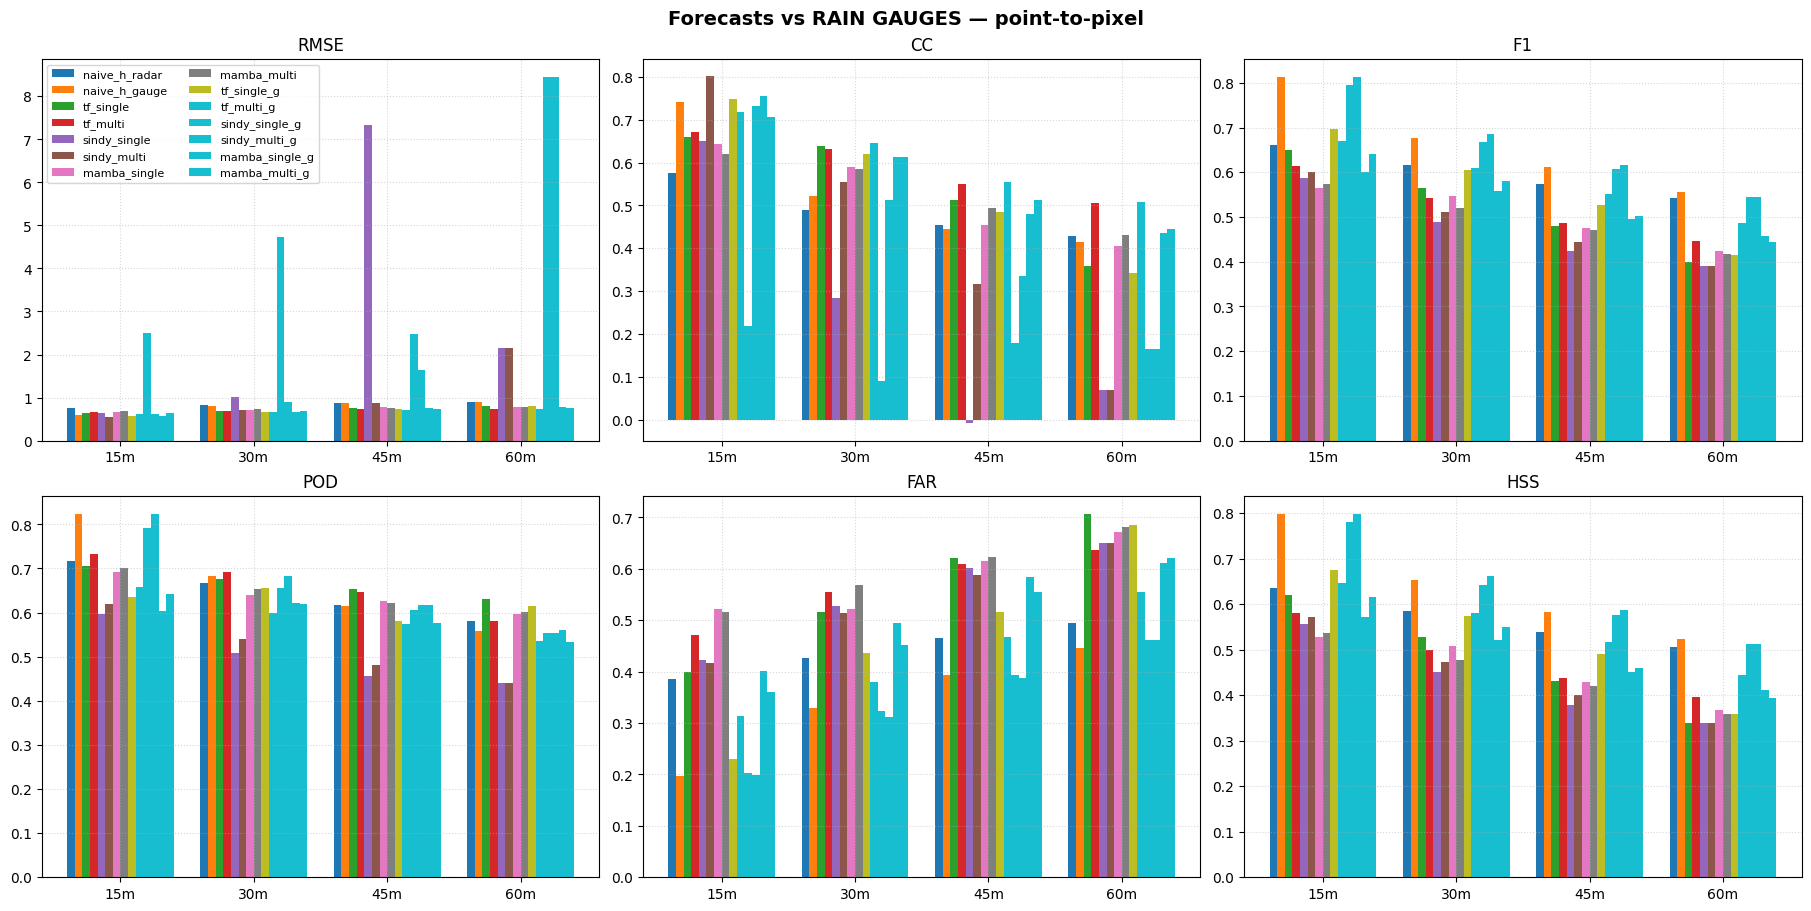

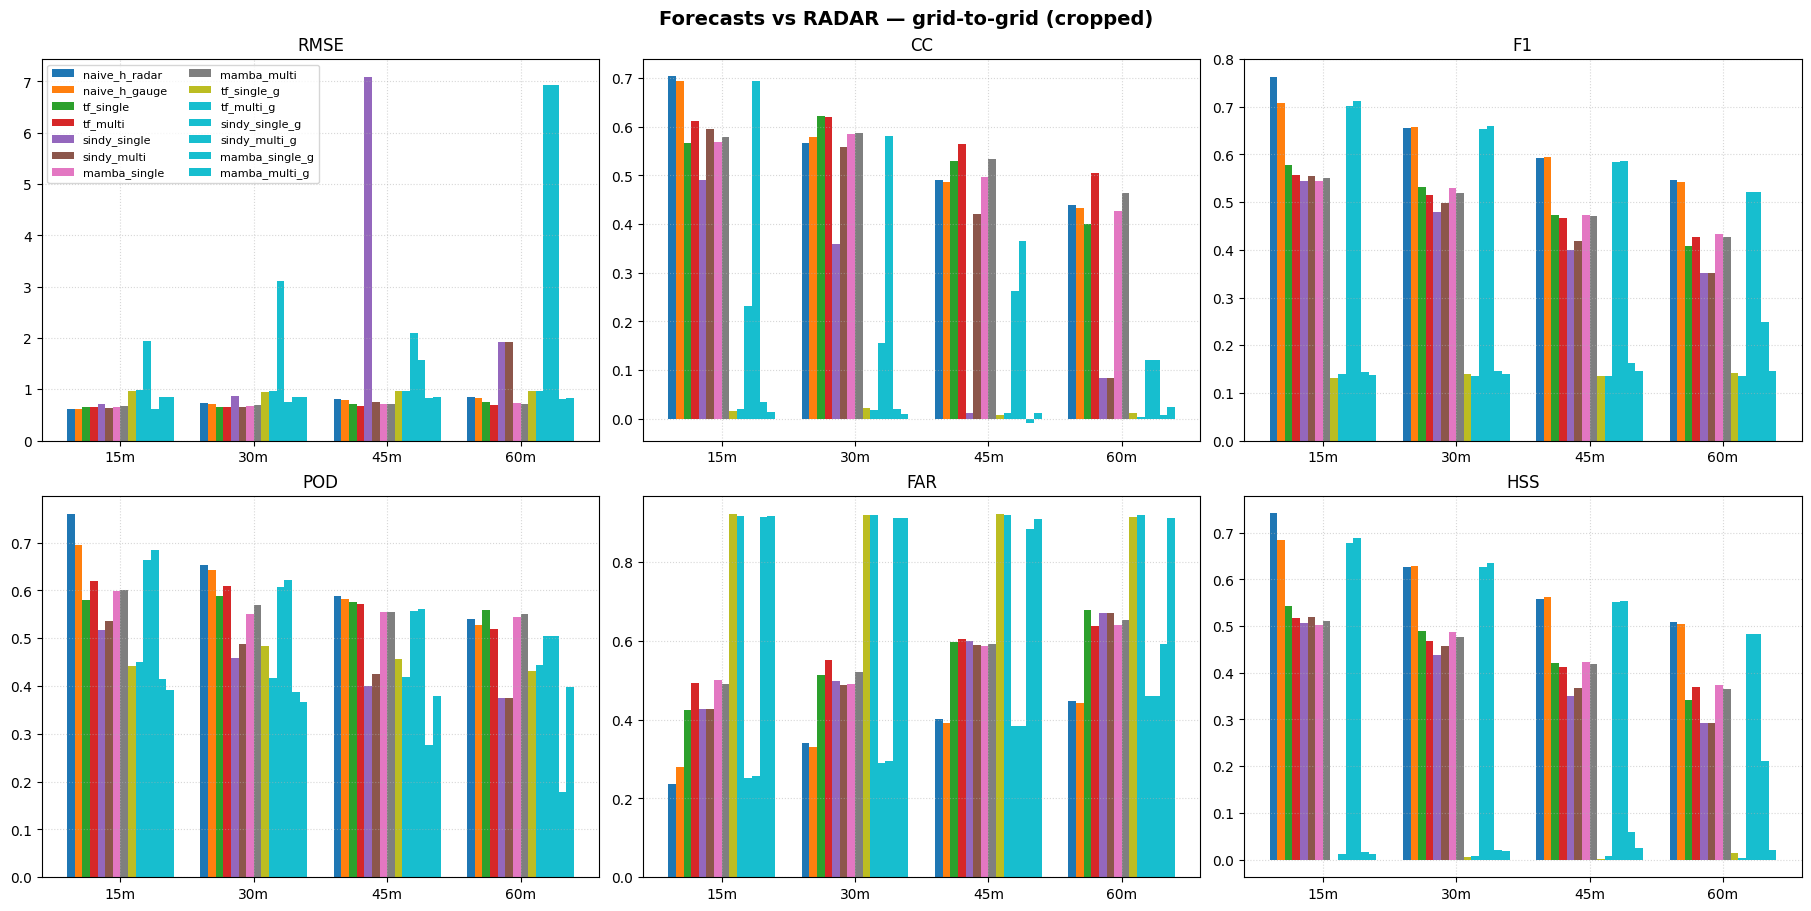

In [ ]:
METRIC_ORDER = ["RMSE", "CC", "F1", "POD", "FAR", "HSS"]

def plot_bars(df, title):
    fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    models = df["model"].unique().tolist()
    n_m = len(models); width = 0.8 / n_m
    cmap = plt.get_cmap("tab10")
    for ax, met in zip(axes.ravel(), METRIC_ORDER):
        for i, m in enumerate(models):
            sub = df[df["model"] == m].sort_values("horizon_min")
            xs = np.arange(len(sub)) + i * width
            ax.bar(xs, sub[met].values, width=width, label=m, color=cmap(i))
        ax.set_xticks(np.arange(len(HORIZONS_MIN)) + width * (n_m - 1) / 2)
        ax.set_xticklabels([f"{h}m" for h in HORIZONS_MIN])
        ax.set_title(met); ax.grid(True, ls=":", alpha=0.5)
    axes.ravel()[0].legend(loc="upper left", fontsize=8, ncol=2)
    plt.show()

plot_bars(df_g, "Forecasts vs RAIN GAUGES — point-to-pixel")
plot_bars(df_r, "Forecasts vs RADAR — grid-to-grid (cropped)")

## Cell 35 — Peak event grid (maps at the wettest test frame)

Pick the test frame with the highest mean rainfall in the cropped
window, then plot side-by-side maps:

* radar ground truth
* every model's prediction at horizon 30 min

Quick visual check that "the storm is in the right place" — much more
informative than scalar metrics for spatial errors.


Peak test frame at 2015-08-25 06:45:00 (mean rain 8.691 mm/h)
Prediction index i_pred = 1842 for horizon 30 min



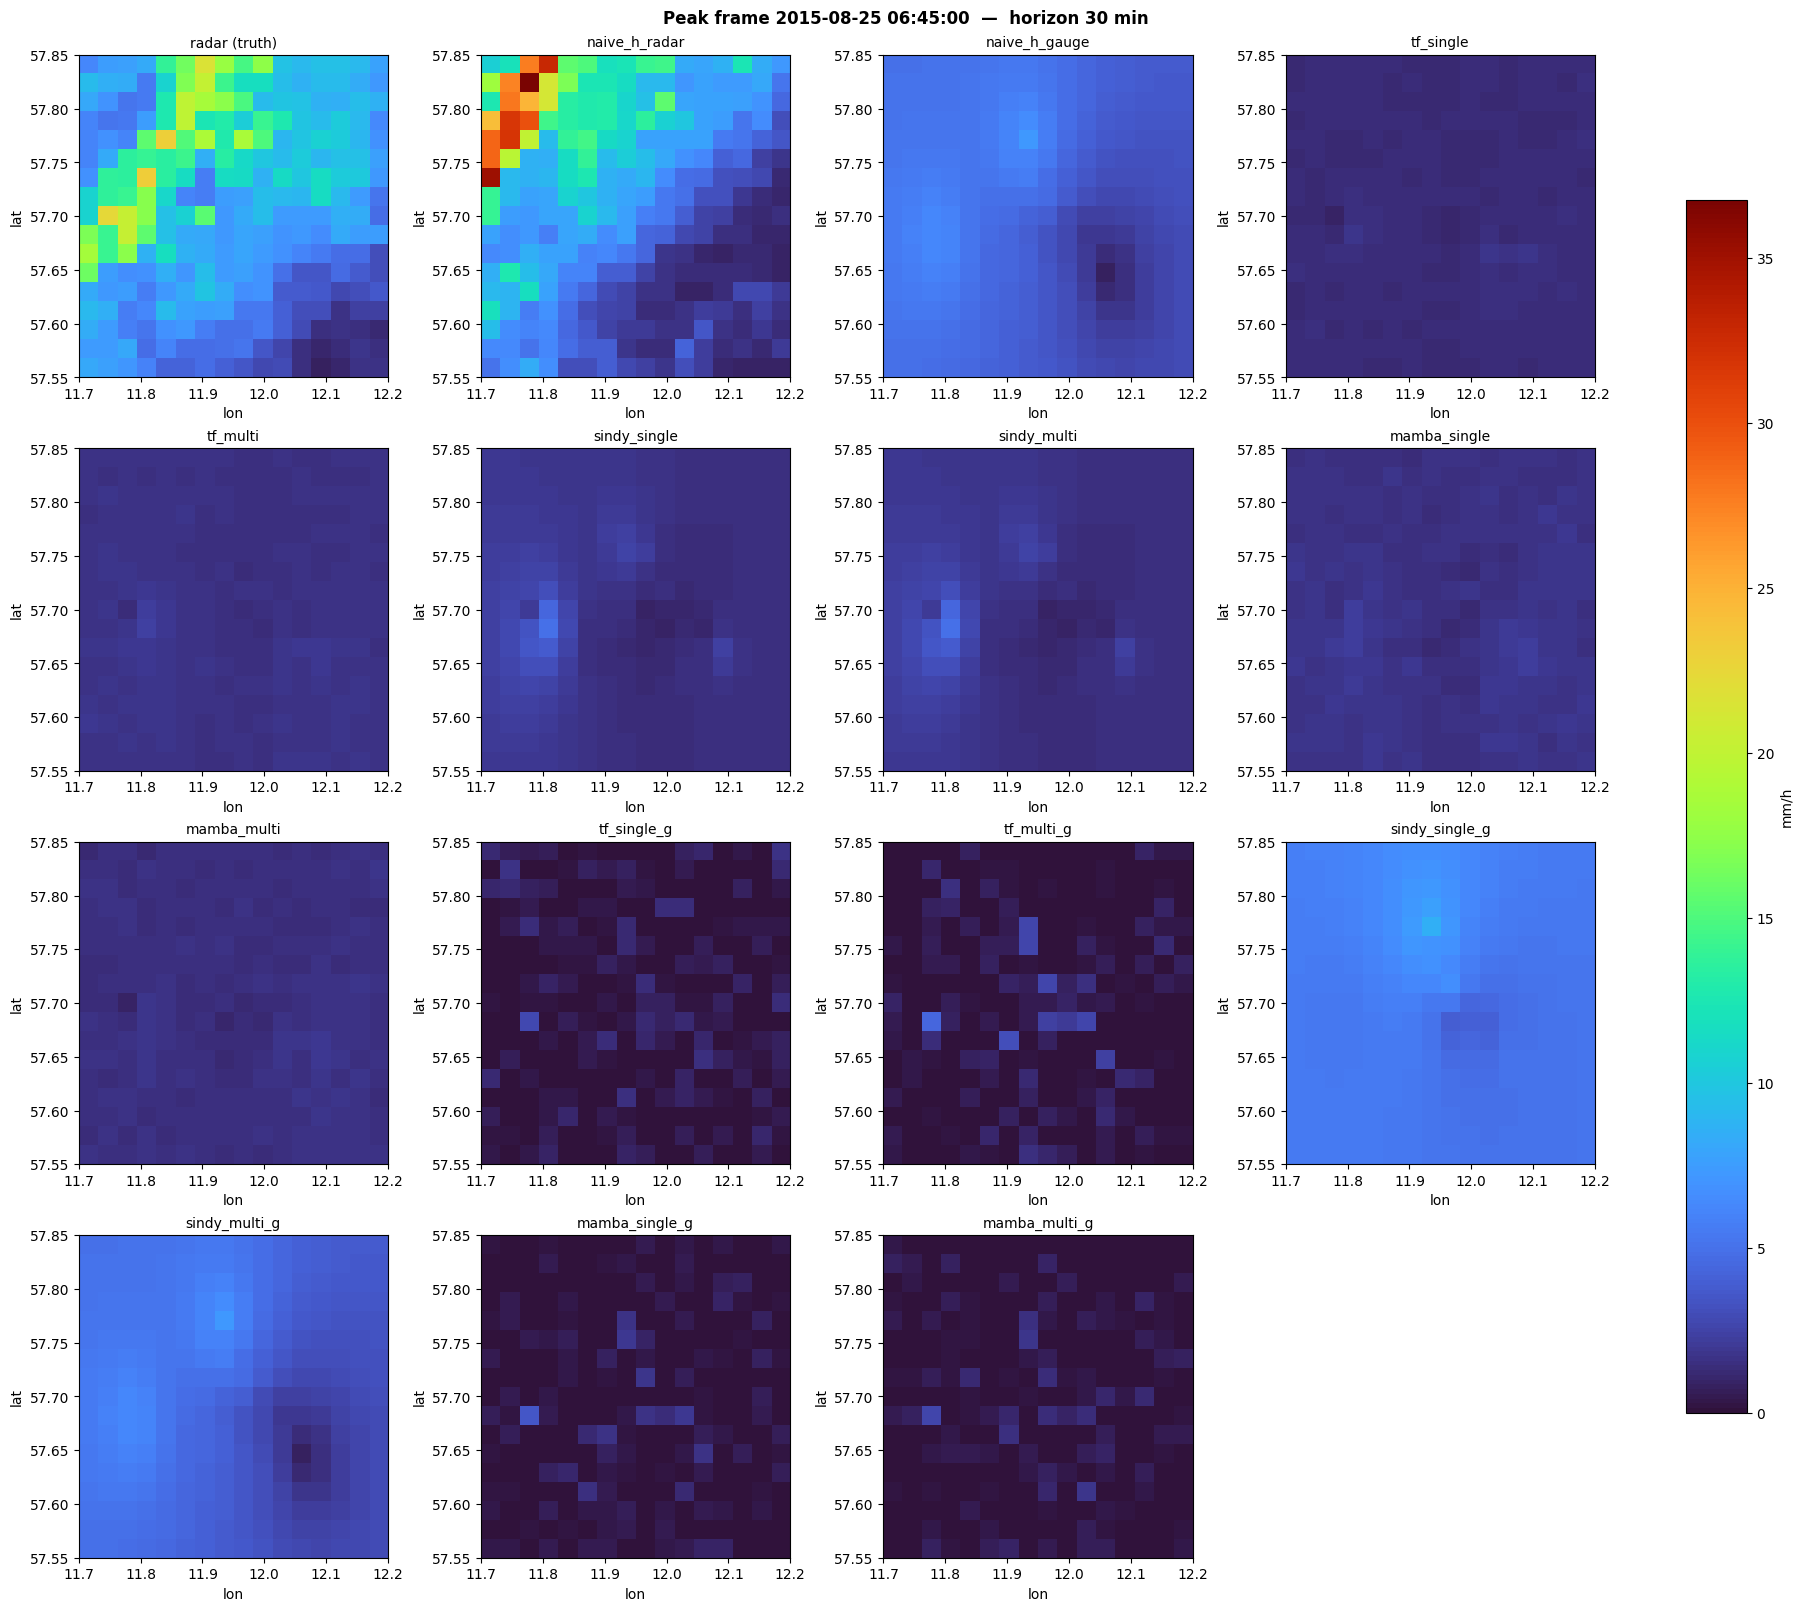

In [ ]:
H_VIZ = 30   # minutes — pick a horizon
h_step_viz = H_VIZ // 15

# pick peak frame in the test window
test_means = crop_field(radar_15)[TEST_LO:TEST_HI].mean(axis=(1, 2))
peak_local = int(np.argmax(test_means))
peak_global = TEST_LO + peak_local

# We need the prediction made *for* time = peak_global
# Forecaster output index: i_pred = peak_global - (TEST_LO + LOOKBACK + h - 1)
i_pred = peak_local - LOOKBACK_WINDOW - h_step_viz + 1
if i_pred < 0:
    i_pred = 0
    peak_local = LOOKBACK_WINDOW + h_step_viz - 1
    peak_global = TEST_LO + peak_local
print(f"Peak test frame at {radar_times[peak_global]} (mean rain {test_means[peak_local]:.3f} mm/h)")
print(f"Prediction index i_pred = {i_pred} for horizon {H_VIZ} min\n")

panels = [("radar (truth)", crop_field(radar_15)[peak_global])]
for mname, mdict in forecasts.items():
    if H_VIZ not in mdict: continue
    pred = mdict[H_VIZ]
    if mname.startswith("naive_"):
        panels.append((mname, crop_field(pred[peak_global])))
    else:
        panels.append((mname, crop_field(pred[i_pred])))

n = len(panels)
cols = 4; rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4.5*cols, 4*rows), constrained_layout=True)
axes = np.atleast_2d(axes)
vmax = max(p[1].max() for p in panels)
norm = mcolors.Normalize(vmin=0, vmax=vmax)
for ax, (name, m) in zip(axes.ravel(), panels):
    im = ax.imshow(m, cmap="turbo", norm=norm, origin="lower",
                   extent=[LON_RANGE[0], LON_RANGE[1], LAT_RANGE[0], LAT_RANGE[1]],
                   aspect="auto")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
for ax in axes.ravel()[len(panels):]:
    ax.axis("off")
fig.suptitle(f"Peak frame {radar_times[peak_global]}  —  horizon {H_VIZ} min",
             fontsize=12, fontweight="bold")
fig.colorbar(im, ax=axes, fraction=0.04, label="mm/h")
plt.show()

## Cell 36 — Summary table

Compact final ranking: which model wins at each horizon on each metric
(against gauges and radar). Saved to
`PROCESSED_DIR/advanced_results.csv` for reference.


In [ ]:
SUM_PATH = os.path.join(PROCESSED_DIR, "advanced_results.csv")

df_g["target"] = "gauges"
df_r["target"] = "radar"
df_all = pd.concat([df_g, df_r], ignore_index=True)
df_all.to_csv(SUM_PATH, index=False)
print(f"Saved {SUM_PATH}  ({len(df_all)} rows)")

print("\n=== BEST MODEL PER (target, horizon, metric) ===")
for tgt in ("gauges", "radar"):
    print(f"\n--- target = {tgt} ---")
    sub = df_all[df_all["target"] == tgt]
    for met in ["RMSE", "MAE", "F1", "CSI", "HSS", "CC"]:
        print(f"  {met}:")
        for h in HORIZONS_MIN:
            ssub = sub[sub["horizon_min"] == h]
            if met in ("RMSE", "MAE", "FAR", "Bias"):
                row = ssub.loc[ssub[met].abs().idxmin()] if met == "Bias" else ssub.loc[ssub[met].idxmin()]
            else:
                row = ssub.loc[ssub[met].idxmax()]
            print(f"    h={h:>3d}m  →  {row['model']:<14s}  ({met}={row[met]:.4f})")

Saved /content/drive/MyDrive/FieldSense_Project/data/processed/advanced_results.csv  (112 rows)

=== BEST MODEL PER (target, horizon, metric) ===

--- target = gauges ---
  RMSE:
    h= 15m  →  sindy_multi     (RMSE=0.5443)
    h= 30m  →  tf_multi_g      (RMSE=0.6597)
    h= 45m  →  tf_multi_g      (RMSE=0.7105)
    h= 60m  →  tf_multi_g      (RMSE=0.7323)
  MAE:
    h= 15m  →  naive_h_gauge   (MAE=0.0868)
    h= 30m  →  tf_multi        (MAE=0.1238)
    h= 45m  →  mamba_multi_g   (MAE=0.1401)
    h= 60m  →  mamba_single_g  (MAE=0.1433)
  F1:
    h= 15m  →  naive_h_gauge   (F1=0.8126)
    h= 30m  →  sindy_multi_g   (F1=0.6855)
    h= 45m  →  sindy_multi_g   (F1=0.6156)
    h= 60m  →  naive_h_gauge   (F1=0.5557)
  CSI:
    h= 15m  →  naive_h_gauge   (CSI=0.6844)
    h= 30m  →  sindy_multi_g   (CSI=0.5215)
    h= 45m  →  sindy_multi_g   (CSI=0.4447)
    h= 60m  →  naive_h_gauge   (CSI=0.3848)
  HSS:
    h= 15m  →  naive_h_gauge   (HSS=0.7988)
    h= 30m  →  sindy_multi_g   (HSS=0.6627)
  